# PRCP-1001 — Rice Leaf Disease Prediction




**Objectives**
1. Audit and analyze the image dataset.
2. Classify **Bacterial leaf blight**, **Brown spot**, and **Leaf smut**.
3. Evaluate the effect of data augmentation.
4. Compare classical computer vision and deep-learning models.
5. Recommend and save a deployment candidate.
6. Document decisions, challenges, limitations, and conclusions.

> **Archive audit:** the brief says 120 images, but the supplied archive contains **119 valid JPG files**: 40 bacterial leaf blight, 40 brown spot, and 39 leaf smut. One task sentence says “leaf blast,” while the class list and actual folder say “Leaf smut.” This notebook follows the actual folder labels.

> **Reliability note:** the test split contains only 18 images. High scores, including a perfect score, must be treated as preliminary evidence rather than real-world agricultural accuracy.


##  Environment check


In [1]:
import importlib.util
import sys

PACKAGE_IMPORTS = {
    "opencv-python": "cv2",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
    "scikit-image": "skimage",
    "pillow": "PIL",
    "joblib": "joblib",
    "torch": "torch",
    "torchvision": "torchvision",
}

missing_packages = [
    package_name
    for package_name, import_name in PACKAGE_IMPORTS.items()
    if importlib.util.find_spec(import_name) is None
]

print("Python environment:", sys.executable)
if missing_packages:
    print("Missing packages:", ", ".join(missing_packages))
    print("Run this once, then restart the kernel:")
    print("%pip install " + " ".join(missing_packages))
else:
    print("All required packages are available.")


Python environment: C:\ProgramData\anaconda3\python.exe
All required packages are available.


##  Imports, reproducibility, and configuration

In [2]:
import os
import json
import time
import copy
import random
import hashlib
import shutil
import warnings
import zipfile
from pathlib import Path

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image, ImageOps, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from skimage.feature import hog
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

warnings.filterwarnings("default")
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| Device:", DEVICE)

PROJECT_ROOT = Path.cwd().resolve()
zip_candidates = [
    PROJECT_ROOT / "PRCP-1001-RiceLeaf.zip",
    Path("/content/PRCP-1001-RiceLeaf.zip"),
    Path("/mnt/data/PRCP-1001-RiceLeaf.zip"),
]
ZIP_PATH = next((path for path in zip_candidates if path.exists()), None)
if ZIP_PATH is None:
    found_archives = sorted(PROJECT_ROOT.glob("*RiceLeaf*.zip"))
    ZIP_PATH = found_archives[0] if found_archives else None
if ZIP_PATH is None or not ZIP_PATH.exists():
    raise FileNotFoundError(
        "Place PRCP-1001-RiceLeaf.zip beside the notebook and run the cell again."
    )

WORK_DIR = PROJECT_ROOT / "riceleaf_workspace"
OUTER_DIR = WORK_DIR / "outer_archive"
DATASET_DIR = WORK_DIR / "dataset"
ARTIFACT_DIR = WORK_DIR / "artifacts"
for directory in [WORK_DIR, OUTER_DIR, DATASET_DIR, ARTIFACT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FAST_MODE = os.getenv("RICELEAF_FAST_MODE", "0") == "1"
USE_PRETRAINED = os.getenv("RICELEAF_USE_PRETRAINED", "1") == "1"
if FAST_MODE:
    IMAGE_SIZE, BATCH_SIZE = (96, 192), 8
    CUSTOM_EPOCHS, HEAD_EPOCHS, FINE_TUNE_EPOCHS = 1, 1, 0
else:
    IMAGE_SIZE, BATCH_SIZE = (224, 448), 8
    CUSTOM_EPOCHS, HEAD_EPOCHS, FINE_TUNE_EPOCHS = 25, 8, 12

EARLY_STOPPING_PATIENCE = 5
NUM_WORKERS = 0
TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15

print("Archive:", ZIP_PATH)
print("Fast mode:", FAST_MODE, "| Image size:", IMAGE_SIZE)


PyTorch: 2.13.0+cpu | Device: cpu
Archive: C:\Users\shank\Downloads\PRCP-1001-RiceLeaf.zip
Fast mode: False | Image size: (224, 448)


##  Extract the outer and nested archives
The supplied archive contains three nested ZIPs. This cell is safe to rerun.

In [3]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def folder_has_images(folder):
    return folder.exists() and any(
        path.is_file() and path.suffix.lower() in VALID_EXTENSIONS
        for path in folder.rglob("*")
    )

def safe_extract(archive, destination):
    """Extract a ZIP while blocking path-traversal entries."""
    destination = destination.resolve()
    for member in archive.infolist():
        target = (destination / member.filename).resolve()
        if target != destination and destination not in target.parents:
            raise RuntimeError(f"Unsafe ZIP member detected: {member.filename}")
    archive.extractall(destination)

def extract_dataset(zip_path, outer_dir, dataset_dir):
    if folder_has_images(dataset_dir):
        print("Dataset already extracted.")
        return

    shutil.rmtree(outer_dir, ignore_errors=True)
    shutil.rmtree(dataset_dir, ignore_errors=True)
    outer_dir.mkdir(parents=True, exist_ok=True)
    dataset_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path) as archive:
        safe_extract(archive, outer_dir)

    nested_archives = sorted(outer_dir.rglob("*.zip"))
    if nested_archives:
        for nested_zip in nested_archives:
            with zipfile.ZipFile(nested_zip) as archive:
                safe_extract(archive, dataset_dir)
            print("Extracted:", nested_zip.name)
    else:
        for item in outer_dir.iterdir():
            destination = dataset_dir / item.name
            if item.is_dir():
                shutil.copytree(item, destination, dirs_exist_ok=True)
            else:
                shutil.copy2(item, destination)

    if not folder_has_images(dataset_dir):
        raise RuntimeError("No supported images were found after extraction.")

extract_dataset(ZIP_PATH, OUTER_DIR, DATASET_DIR)
CLASS_FOLDERS = sorted(
    [
        path for path in DATASET_DIR.iterdir()
        if path.is_dir() and folder_has_images(path)
    ],
    key=lambda path: path.name.lower(),
)

if len(CLASS_FOLDERS) != 3:
    raise RuntimeError(
        f"Expected three disease folders but found {len(CLASS_FOLDERS)}: "
        f"{[path.name for path in CLASS_FOLDERS]}"
    )

print("Classes:", [path.name for path in CLASS_FOLDERS])


Dataset already extracted.
Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


##  Dataset audit and image-quality analysis
The audit checks counts, corruption, dimensions, aspect ratio, brightness, contrast, blur, and exact duplicates. Images are not automatically deleted because the dataset is extremely small.

In [4]:
def md5_file(path):
    digest = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            digest.update(chunk)
    return digest.hexdigest()

records, corrupt_files = [], []
for class_folder in CLASS_FOLDERS:
    for image_path in sorted(class_folder.iterdir()):
        if not image_path.is_file() or image_path.suffix.lower() not in VALID_EXTENSIONS:
            continue
        try:
            with Image.open(image_path) as image:
                image.verify()
            with Image.open(image_path) as image:
                image = image.convert("RGB")
                arr = np.asarray(image)
                gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
                h, w = gray.shape
                records.append({
                    "path": str(image_path.resolve()), "filename": image_path.name,
                    "label": class_folder.name, "width": w, "height": h,
                    "aspect_ratio": w / h, "file_size_kb": image_path.stat().st_size / 1024,
                    "mean_red": arr[:, :, 0].mean(), "mean_green": arr[:, :, 1].mean(),
                    "mean_blue": arr[:, :, 2].mean(), "brightness": gray.mean(),
                    "contrast": gray.std(),
                    "blur_variance": cv2.Laplacian(gray, cv2.CV_64F).var(),
                    "md5": md5_file(image_path),
                })
        except Exception as error:
            corrupt_files.append({"path": str(image_path), "error": repr(error)})

df_images = pd.DataFrame(records).sort_values(["label", "filename"]).reset_index(drop=True)
print("Valid images:", len(df_images), "| Corrupt images:", len(corrupt_files))
display(df_images.head())

counts = df_images["label"].value_counts().sort_index()
display(counts.rename("image_count").to_frame())
if len(df_images) != 120:
    print(f"Audit finding: expected 120, supplied archive contains {len(df_images)} valid images.")

duplicates = df_images[df_images.duplicated("md5", keep=False)]
print("Exact duplicate groups:", duplicates["md5"].nunique())
if not duplicates.empty:
    display(duplicates[["label", "filename", "md5"]])

display(df_images[["width", "height", "aspect_ratio", "file_size_kb", "brightness", "contrast", "blur_variance"]].describe().T.round(2))

Valid images: 119 | Corrupt images: 0


,path,filename,label,width,height,aspect_ratio,file_size_kb,mean_red,mean_green,mean_blue,brightness,contrast,blur_variance,md5
0,C:\Users\shank\Downloads\riceleaf_workspace\da...,DSC_0365.JPG,Bacterial leaf blight,3081,897,3.434783,456.161133,196.807981,187.391320,163.822809,187.549087,51.045984,22.270062,5d87c57aa5f018efc329a61b1f0b4b9a
1,C:\Users\shank\Downloads\riceleaf_workspace\da...,DSC_0366.jpg,Bacterial leaf blight,3081,897,3.434783,408.133789,194.008195,185.150240,159.361242,184.890575,52.231429,11.457631,849f11bd956069ea3bfd89cf7d36e216
2,C:\Users\shank\Downloads\riceleaf_workspace\da...,DSC_0367.JPG,Bacterial leaf blight,3081,897,3.434783,442.016602,196.319661,189.777191,154.965337,187.808899,51.377089,20.992710,f89063b62e714c5245f6042608981366
3,C:\Users\shank\Downloads\riceleaf_workspace\da...,DSC_0370.jpg,Bacterial leaf blight,3081,897,3.434783,418.683594,174.994122,171.421583,131.211476,167.970084,66.187975,9.596223,bf54079d9e7b11cafaeea6fa02884fac
4,C:\Users\shank\Downloads\riceleaf_workspace\da...,DSC_0372.JPG,Bacterial leaf blight,3081,897,3.434783,470.204102,190.695603,186.268642,143.503484,182.701673,56.050450,33.061685,8eaceece91d9c6dfb524450168c8ba08


,image_count
label,
Bacterial leaf blight,40
Brown spot,40
Leaf smut,39


Audit finding: expected 120, supplied archive contains 119 valid images.
Exact duplicate groups: 0


,count,mean,std,min,25%,50%,75%,max
width,119.0,2383.64,1123.53,250.00,1074.00,3081.00,3081.00,3081.00
height,119.0,707.74,311.66,71.00,377.00,897.00,897.00,900.00
aspect_ratio,119.0,3.33,0.65,1.25,3.43,3.43,3.43,5.30
file_size_kb,119.0,307.77,172.70,22.76,102.66,379.45,426.88,643.40
brightness,119.0,182.03,24.47,89.50,175.59,187.37,196.27,235.30
contrast,119.0,53.53,10.49,17.52,49.15,52.91,57.68,86.55
blur_variance,119.0,172.95,292.47,3.46,8.70,20.57,222.64,1316.26


### Audit inference
The classes are nearly balanced, so aggressive oversampling is unnecessary. The main risks are the tiny sample size, mixed resolution, long aspect ratio, variable background, and similar lesion appearance. This justifies stratified splitting, augmentation only on training data, aspect-ratio-preserving preprocessing, transfer learning, early stopping, and macro-averaged metrics.

##  Exploratory data analysis (EDA)

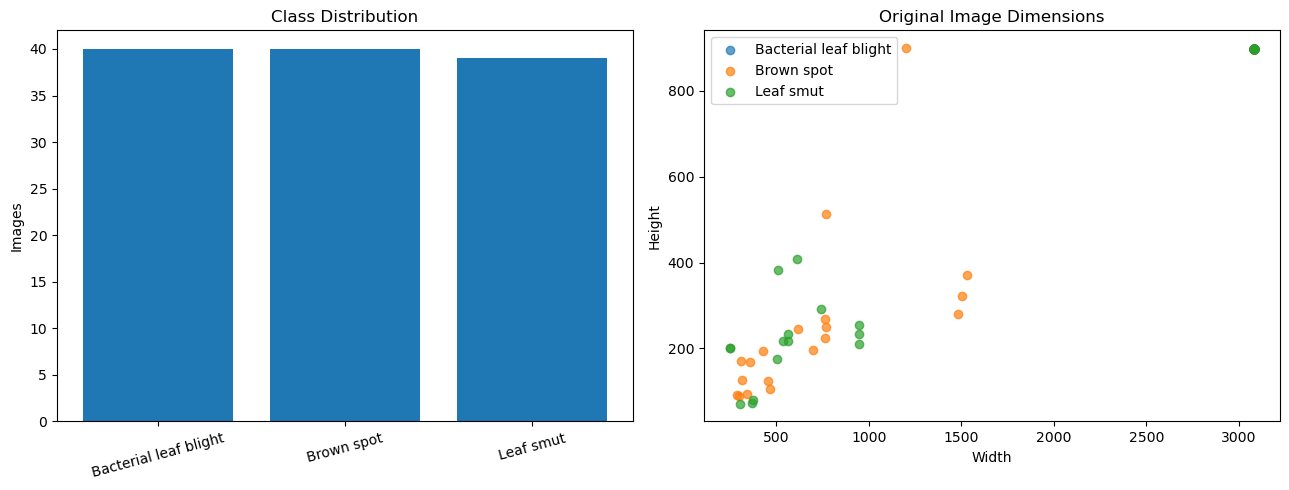

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(counts.index, counts.values)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Images")
axes[0].tick_params(axis="x", rotation=15)

for class_name in sorted(df_images["label"].unique()):
    subset = df_images[df_images["label"] == class_name]
    axes[1].scatter(subset["width"], subset["height"], alpha=0.7, label=class_name)
axes[1].set_title("Original Image Dimensions")
axes[1].set_xlabel("Width")
axes[1].set_ylabel("Height")
axes[1].legend()
plt.tight_layout()
plt.show()

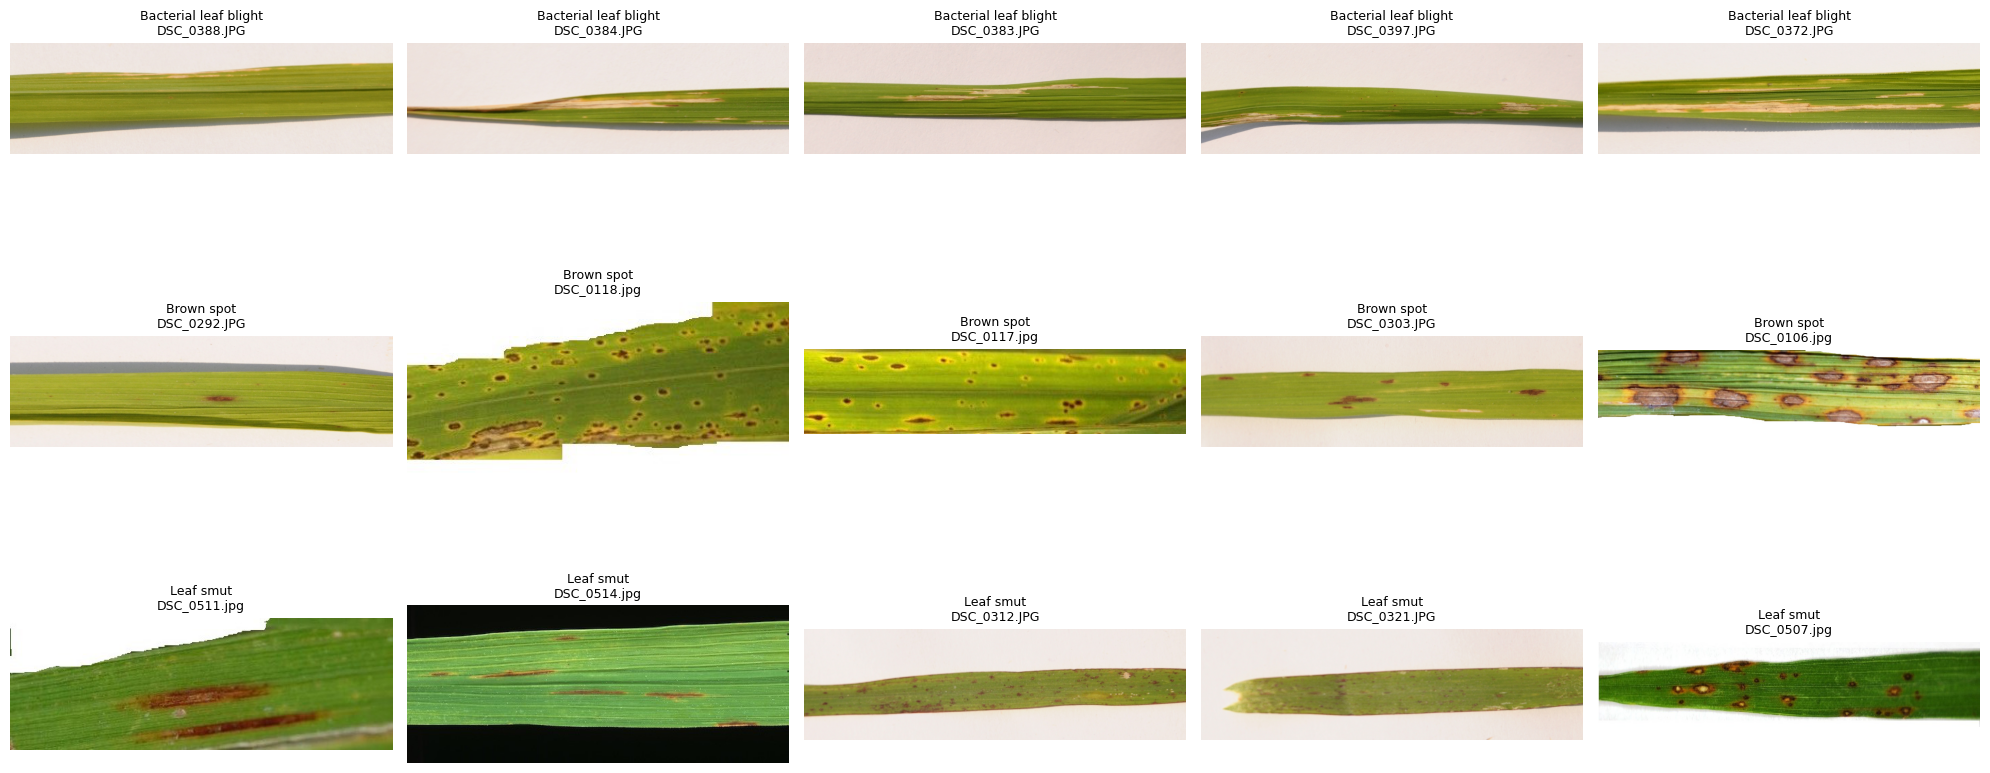

In [6]:
def show_samples(dataframe, samples_per_class=5):
    classes = sorted(dataframe["label"].unique())
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(4*samples_per_class, 3.2*len(classes)))
    axes = np.atleast_2d(axes)
    for row, class_name in enumerate(classes):
        samples = dataframe[dataframe["label"] == class_name].sample(
            min(samples_per_class, (dataframe["label"] == class_name).sum()),
            random_state=SEED,
        )
        for col, (_, item) in enumerate(samples.iterrows()):
            with Image.open(item["path"]) as image:
                axes[row, col].imshow(image.convert("RGB"))
            axes[row, col].set_title(f"{class_name}\n{item['filename']}", fontsize=9)
            axes[row, col].axis("off")
    plt.tight_layout()
    plt.show()

show_samples(df_images)

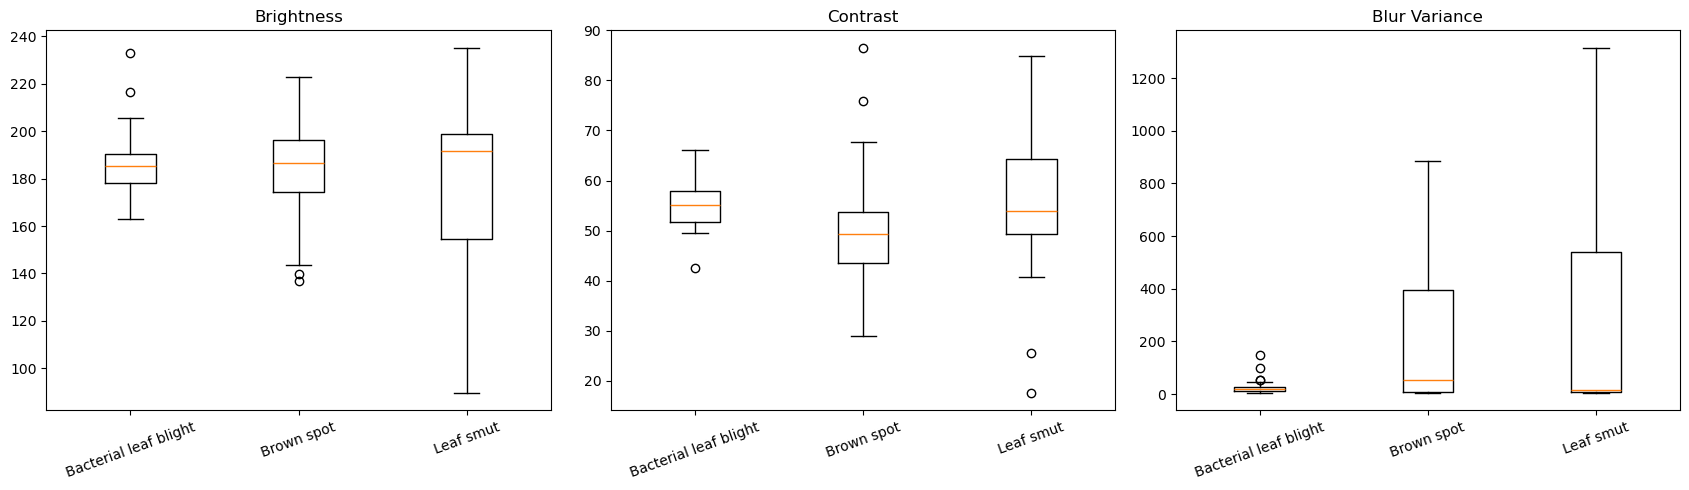

,label,filename,width,height,blur_variance
38,Bacterial leaf blight,DSC_0702.jpg,3081,897,3.455965
61,Brown spot,DSC_0296.jpg,3081,897,4.730307
98,Leaf smut,DSC_0331.JPG,3081,897,5.145564
39,Bacterial leaf blight,DSC_0703.JPG,3081,897,5.312137
64,Brown spot,DSC_0301.JPG,3081,897,5.376407
76,Brown spot,DSC_0333.JPG,3081,897,5.577566
72,Brown spot,DSC_0324.JPG,3081,897,5.618950
62,Brown spot,DSC_0299.JPG,3081,897,5.674554


,mean_red,mean_green,mean_blue
label,,,
Bacterial leaf blight,194.20,188.88,152.22
Brown spot,191.29,189.45,126.63
Leaf smut,180.11,181.93,141.39


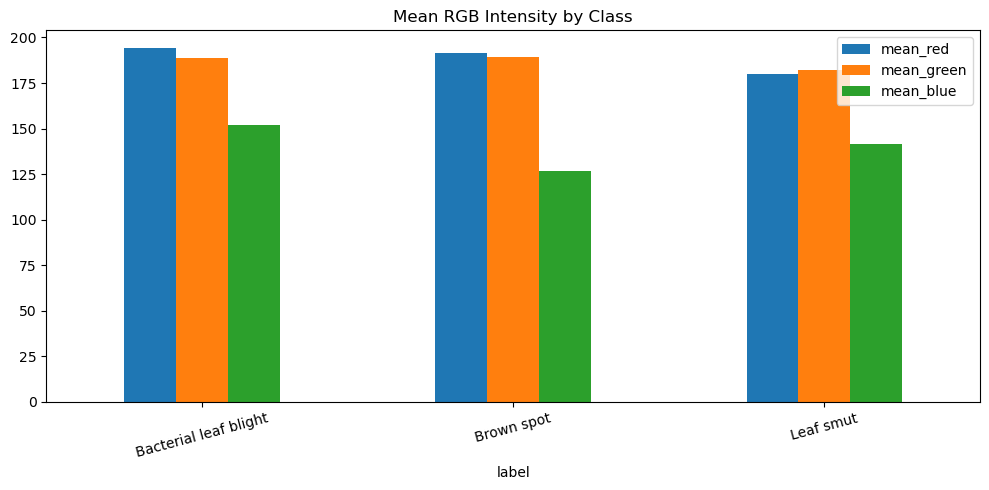

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for axis, metric in zip(axes, ["brightness", "contrast", "blur_variance"]):
    values = [
        df_images.loc[df_images["label"] == class_name, metric].values
        for class_name in sorted(df_images["label"].unique())
    ]
    axis.boxplot(values, tick_labels=sorted(df_images["label"].unique()), showfliers=True)
    axis.set_title(metric.replace("_", " ").title())
    axis.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

display(df_images.nsmallest(8, "blur_variance")[["label", "filename", "width", "height", "blur_variance"]])

channel_summary = df_images.groupby("label")[["mean_red", "mean_green", "mean_blue"]].mean().round(2)
display(channel_summary)
channel_summary.plot(kind="bar", figsize=(10, 5), title="Mean RGB Intensity by Class")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##  Label encoding and stratified train-validation-test split
The split is approximately 70% train, 15% validation, and 15% untouched test. The validation set supports early stopping; the test set is used only for final comparison.

In [8]:
CLASS_NAMES = sorted(df_images["label"].unique())
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
INDEX_TO_CLASS = {index: name for name, index in CLASS_TO_INDEX.items()}

df_model = df_images[["path", "filename", "label"]].copy()
df_model["label_index"] = df_model["label"].map(CLASS_TO_INDEX)

train_val_df, test_df = train_test_split(
    df_model, test_size=TEST_SIZE, stratify=df_model["label_index"], random_state=SEED
)
adjusted_validation_size = VALIDATION_SIZE / (1 - TEST_SIZE)
train_df, validation_df = train_test_split(
    train_val_df,
    test_size=adjusted_validation_size,
    stratify=train_val_df["label_index"],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.concat([
    train_df["label"].value_counts().rename("train"),
    validation_df["label"].value_counts().rename("validation"),
    test_df["label"].value_counts().rename("test"),
], axis=1).fillna(0).astype(int).sort_index()
display(split_summary)
print(len(train_df), "train |", len(validation_df), "validation |", len(test_df), "test")

assert set(train_df["path"]).isdisjoint(validation_df["path"])
assert set(train_df["path"]).isdisjoint(test_df["path"])
assert set(validation_df["path"]).isdisjoint(test_df["path"])

train_df.to_csv(ARTIFACT_DIR / "train_split.csv", index=False)
validation_df.to_csv(ARTIFACT_DIR / "validation_split.csv", index=False)
test_df.to_csv(ARTIFACT_DIR / "test_split.csv", index=False)
with open(ARTIFACT_DIR / "class_mapping.json", "w", encoding="utf-8") as f:
    json.dump(CLASS_TO_INDEX, f, indent=2)

,train,validation,test
label,,,
Bacterial leaf blight,28,6,6
Brown spot,28,6,6
Leaf smut,27,6,6


83 train | 18 validation | 18 test


##  Aspect-ratio-preserving preprocessing and data augmentation
Square resizing would compress these long leaves. `ResizeWithPad` preserves geometry and estimates a border color from each image. Training augmentation uses mild flips, rotation, translation, scale, and color jitter. Random cropping is avoided because it could remove small lesions.

In [9]:
def estimate_border_color(image):
    arr = np.asarray(image.convert("RGB"))
    h, w = arr.shape[:2]
    border = max(1, min(h, w) // 25)
    pixels = np.concatenate([
        arr[:border].reshape(-1, 3), arr[-border:].reshape(-1, 3),
        arr[:, :border].reshape(-1, 3), arr[:, -border:].reshape(-1, 3),
    ])
    return tuple(np.median(pixels, axis=0).astype(np.uint8).tolist())

class ResizeWithPad:
    """Resize without distorting the long leaf geometry, then pad to target size."""
    def __init__(self, target_size):
        self.target_height, self.target_width = target_size
    def __call__(self, image):
        image = image.convert("RGB")
        original_width, original_height = image.size
        scale = min(self.target_width/original_width, self.target_height/original_height)
        new_width = max(1, int(round(original_width * scale)))
        new_height = max(1, int(round(original_height * scale)))
        image = TF.resize(
            image, [new_height, new_width],
            interpolation=InterpolationMode.BILINEAR, antialias=True,
        )
        horizontal = self.target_width - new_width
        vertical = self.target_height - new_height
        left, top = horizontal // 2, vertical // 2
        return TF.pad(
            image,
            [left, top, horizontal-left, vertical-top],
            fill=estimate_border_color(image),
            padding_mode="constant",
        )

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

plain_transform = transforms.Compose([
    ResizeWithPad(IMAGE_SIZE), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
augmented_transform = transforms.Compose([
    ResizeWithPad(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.35),
    transforms.RandomRotation(8, interpolation=InterpolationMode.BILINEAR, fill=(255,255,255)),
    transforms.RandomAffine(
        0, translate=(0.04,0.04), scale=(0.92,1.08),
        interpolation=InterpolationMode.BILINEAR, fill=(255,255,255),
    ),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.10, hue=0.02),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
evaluation_transform = plain_transform

class RiceLeafDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        with Image.open(row["path"]) as image:
            tensor = self.transform(image.convert("RGB"))
        return tensor, int(row["label_index"]), row["path"]

train_plain_dataset = RiceLeafDataset(train_df, plain_transform)
train_augmented_dataset = RiceLeafDataset(train_df, augmented_transform)
validation_dataset = RiceLeafDataset(validation_df, evaluation_transform)
test_dataset = RiceLeafDataset(test_df, evaluation_transform)

loader_args = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=DEVICE.type=="cuda")
train_plain_loader = DataLoader(train_plain_dataset, shuffle=True, **loader_args)
train_augmented_loader = DataLoader(train_augmented_dataset, shuffle=True, **loader_args)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_args)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_args)
print("Data loaders ready.")


Data loaders ready.


### Visualize augmentation
Augmented images should remain plausible. Reduce ranges if lesions become unrealistic.

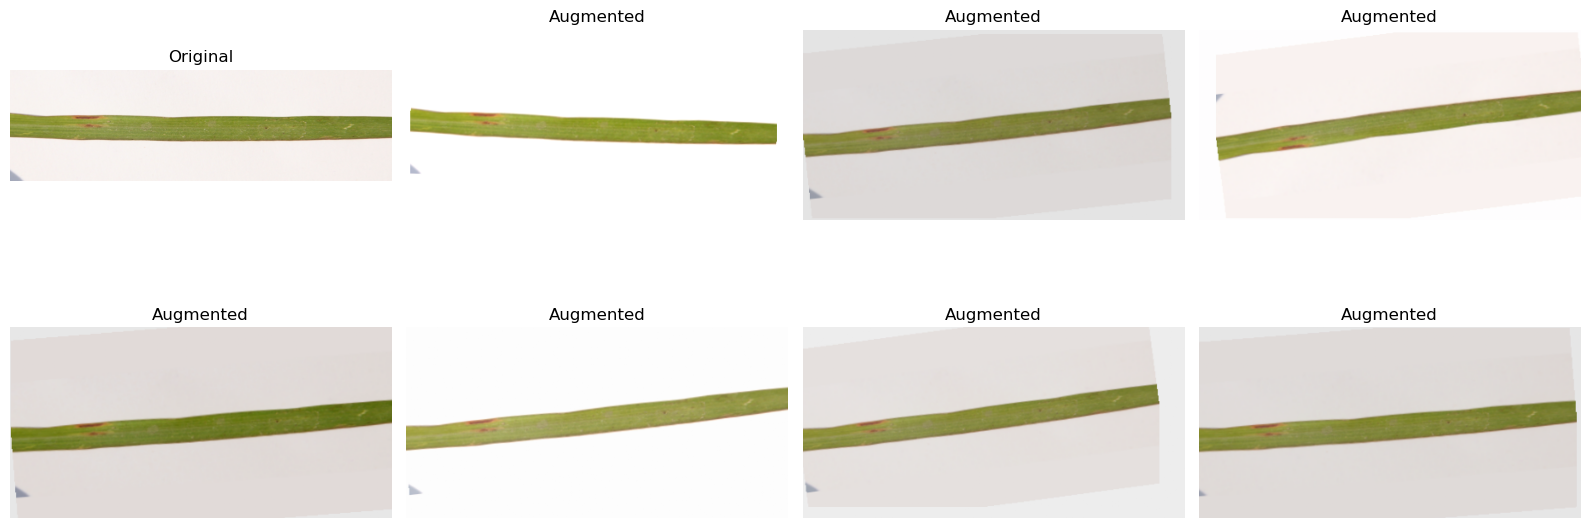

,class,train_count,loss_weight
0,Bacterial leaf blight,28,0.9881
1,Brown spot,28,0.9881
2,Leaf smut,27,1.0247


In [10]:
def denormalize(tensor):
    tensor = tensor.detach()
    mean = torch.as_tensor(
        IMAGENET_MEAN, dtype=tensor.dtype, device=tensor.device
    ).view(3, 1, 1)
    std = torch.as_tensor(
        IMAGENET_STD, dtype=tensor.dtype, device=tensor.device
    ).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

sample_index = 0
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
with Image.open(train_df.iloc[sample_index]["path"]) as image:
    axes[0,0].imshow(image.convert("RGB"))
axes[0,0].set_title("Original")
axes[0,0].axis("off")
for axis in axes.flat[1:]:
    image_tensor, _, _ = train_augmented_dataset[sample_index]
    axis.imshow(denormalize(image_tensor).cpu().permute(1, 2, 0).numpy())
    axis.set_title("Augmented")
    axis.axis("off")
plt.tight_layout()
plt.show()

training_counts = np.bincount(train_df["label_index"], minlength=len(CLASS_NAMES))
class_weights = len(train_df) / (len(CLASS_NAMES) * training_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
display(pd.DataFrame({"class": CLASS_NAMES, "train_count": training_counts, "loss_weight": class_weights}).round(4))


# Part A — Classical computer-vision baseline
##  HOG + HSV features with an RBF SVM
HOG captures local texture and edges; HSV histograms add coarse color information. The RBF SVM is tuned with stratified 5-fold cross-validation using macro F1. This is an important small-data baseline.

In [11]:
HOG_IMAGE_SIZE = (256, 128)  # width, height

def resize_for_features(image):
    image = image.convert("RGB")
    return ImageOps.pad(
        image, HOG_IMAGE_SIZE, method=Image.Resampling.BILINEAR,
        color=estimate_border_color(image), centering=(0.5,0.5),
    )

def extract_handcrafted_features(image_path):
    with Image.open(image_path) as image:
        image = resize_for_features(image)
    rgb = np.asarray(image)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    hog_vector = hog(
        gray, orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2),
        block_norm="L2-Hys", transform_sqrt=True, feature_vector=True,
    )
    color_vector = []
    for channel, bins, value_range in [(0,24,(0,180)), (1,24,(0,256)), (2,24,(0,256))]:
        histogram, _ = np.histogram(
            hsv[:,:,channel], bins=bins, range=value_range, density=True
        )
        color_vector.extend(histogram)
    return np.concatenate([hog_vector, np.asarray(color_vector, dtype=np.float32)])

def build_feature_matrix(dataframe):
    X = np.vstack([extract_handcrafted_features(path) for path in dataframe["path"]])
    y = dataframe["label_index"].to_numpy()
    return X, y

X_train_hog, y_train_hog = build_feature_matrix(train_df)
X_test_hog, y_test_hog = build_feature_matrix(test_df)
print("HOG train:", X_train_hog.shape, "| HOG test:", X_test_hog.shape)

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED)),
])
svm_grid = (
    {"classifier__C": [1], "classifier__gamma": ["scale"]}
    if FAST_MODE else
    {"classifier__C": [0.1,1,10,50], "classifier__gamma": ["scale",0.001,0.01,0.1]}
)
svm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
svm_search = GridSearchCV(
    svm_pipeline, svm_grid, scoring="f1_macro", cv=svm_cv,
    n_jobs=1, refit=True, return_train_score=True,
)
start = time.perf_counter()
svm_search.fit(X_train_hog, y_train_hog)
print("Best parameters:", svm_search.best_params_)
print("Best CV macro F1:", round(svm_search.best_score_, 4))
print("Training seconds:", round(time.perf_counter()-start, 2))

HOG train: (83, 3852) | HOG test: (18, 3852)
Best parameters: {'classifier__C': 10, 'classifier__gamma': 'scale'}
Best CV macro F1: 0.5949
Training seconds: 4.74


##  Evaluation utilities
Macro F1 is the primary metric because it balances precision and recall and gives every class equal importance. The test set contains only about 18 images, so every error changes the score substantially.

,family,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc_ovr,parameters_millions,latency_ms_per_image
model,,,,,,,,,
HOG + HSV + RBF SVM,Classical ML,0.8889,0.9167,0.8889,0.8857,0.8857,0.9815,NaN,0.2648


,precision,recall,f1-score,support
Bacterial leaf blight,1.0000,1.0000,1.0000,6.0000
Brown spot,1.0000,0.6667,0.8000,6.0000
Leaf smut,0.7500,1.0000,0.8571,6.0000
accuracy,0.8889,0.8889,0.8889,0.8889
macro avg,0.9167,0.8889,0.8857,18.0000
weighted avg,0.9167,0.8889,0.8857,18.0000


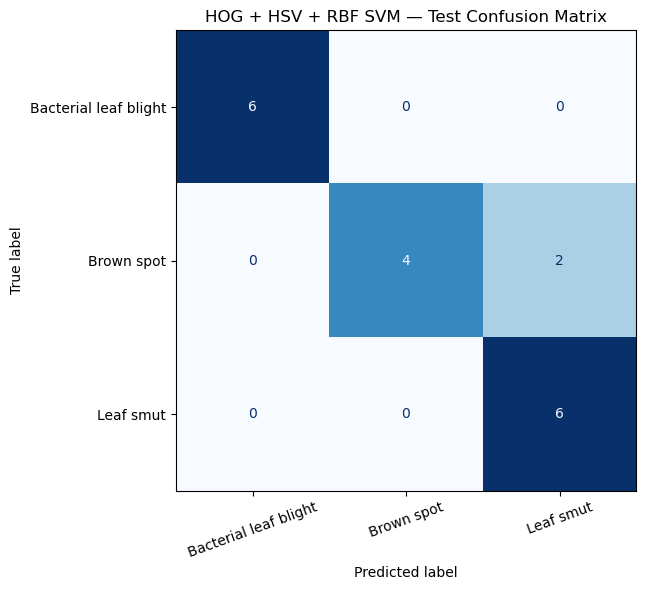

In [12]:
def calculate_metrics(y_true, y_pred, probabilities):
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    try:
        macro_auc = roc_auc_score(y_true, probabilities, multi_class="ovr", average="macro")
    except ValueError:
        macro_auc = np.nan
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_roc_auc_ovr": macro_auc,
    }

def report_dataframe(y_true, y_pred):
    report = classification_report(
        y_true, y_pred, labels=list(range(len(CLASS_NAMES))),
        target_names=CLASS_NAMES, output_dict=True, zero_division=0,
    )
    return pd.DataFrame(report).T

def plot_confusion(y_true, y_pred, title):
    matrix = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
    fig, axis = plt.subplots(figsize=(7,6))
    ConfusionMatrixDisplay(matrix, display_labels=CLASS_NAMES).plot(
        ax=axis, cmap="Blues", colorbar=False, values_format="d"
    )
    axis.set_title(title)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

results, prediction_store, classification_reports = [], {}, {}

start = time.perf_counter()
svm_probabilities = svm_search.predict_proba(X_test_hog)
svm_latency = (time.perf_counter()-start) / len(test_df) * 1000
svm_predictions = svm_probabilities.argmax(axis=1)
svm_result = {
    "model": "HOG + HSV + RBF SVM", "family": "Classical ML",
    **calculate_metrics(y_test_hog, svm_predictions, svm_probabilities),
    "parameters_millions": np.nan, "latency_ms_per_image": svm_latency,
}
results.append(svm_result)
classification_reports[svm_result["model"]] = report_dataframe(y_test_hog, svm_predictions)
prediction_store[svm_result["model"]] = pd.DataFrame({
    "path": test_df["path"], "true_index": y_test_hog, "predicted_index": svm_predictions,
    "true_label": [INDEX_TO_CLASS[i] for i in y_test_hog],
    "predicted_label": [INDEX_TO_CLASS[i] for i in svm_predictions],
    "confidence": svm_probabilities.max(axis=1),
})
display(pd.DataFrame([svm_result]).set_index("model").round(4))
display(classification_reports[svm_result["model"]].round(4))
plot_confusion(y_test_hog, svm_predictions, "HOG + HSV + RBF SVM — Test Confusion Matrix")

# Part B — Deep learning
##  Model definitions
Experiments: custom CNN without augmentation, custom CNN with augmentation, ResNet18 transfer learning, and MobileNetV3-Small transfer learning. Transfer models first learn a new classifier head, then optionally fine-tune the final feature block with a smaller learning rate.

In [13]:
class CustomRiceLeafCNN(nn.Module):
    def __init__(self, number_of_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(), nn.Dropout(0.45),
            nn.Linear(256, number_of_classes),
        )
    def forward(self, images):
        return self.classifier(self.features(images))

def build_model(architecture, number_of_classes, use_pretrained=USE_PRETRAINED):
    pretrained_loaded = False
    if architecture == "custom_cnn":
        return CustomRiceLeafCNN(number_of_classes), pretrained_loaded

    if architecture == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if use_pretrained else None
        try:
            model = models.resnet18(weights=weights)
            pretrained_loaded = weights is not None
        except Exception as error:
            print("Pretrained ResNet18 unavailable; using random initialization.", repr(error))
            model = models.resnet18(weights=None)
        features = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(0.40), nn.Linear(features, number_of_classes))

    elif architecture == "mobilenet_v3_small":
        weights = models.MobileNet_V3_Small_Weights.DEFAULT if use_pretrained else None
        try:
            model = models.mobilenet_v3_small(weights=weights)
            pretrained_loaded = weights is not None
        except Exception as error:
            print("Pretrained MobileNetV3 unavailable; using random initialization.", repr(error))
            model = models.mobilenet_v3_small(weights=None)
        features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(features, number_of_classes)
    else:
        raise ValueError(f"Unsupported architecture: {architecture}")

    if pretrained_loaded:
        for parameter in model.parameters():
            parameter.requires_grad = False
        trainable_head = model.fc if architecture == "resnet18" else model.classifier
        for parameter in trainable_head.parameters():
            parameter.requires_grad = True
    return model, pretrained_loaded

def unfreeze_final_block(model, architecture):
    if architecture == "resnet18":
        modules = [model.layer4, model.fc]
    else:
        modules = [*model.features[-3:], model.classifier]
    for module in modules:
        for parameter in module.parameters():
            parameter.requires_grad = True

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

##  Training loop
Training uses weighted cross-entropy, AdamW, ReduceLROnPlateau, early stopping, best-checkpoint restoration, and CUDA mixed precision when available. These controls reduce overfitting on the tiny training set.

In [14]:
def unpack_batch(batch):
    return batch[0].to(DEVICE, non_blocking=True), batch[1].to(DEVICE, non_blocking=True)

def make_grad_scaler():
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        return torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
    return torch.cuda.amp.GradScaler(enabled=DEVICE.type == "cuda")

def autocast_context():
    if hasattr(torch, "amp") and hasattr(torch.amp, "autocast"):
        return torch.amp.autocast(
            device_type=DEVICE.type, enabled=DEVICE.type == "cuda"
        )
    return torch.cuda.amp.autocast(enabled=DEVICE.type == "cuda")

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = total_correct = total_samples = 0
    for batch in loader:
        images, labels = unpack_batch(batch)
        optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_samples += labels.size(0)
    return total_loss/total_samples, total_correct/total_samples

@torch.no_grad()
def evaluate_loss_accuracy(model, loader, criterion):
    model.eval()
    total_loss = total_correct = total_samples = 0
    for batch in loader:
        images, labels = unpack_batch(batch)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_samples += labels.size(0)
    return total_loss/total_samples, total_correct/total_samples

def fit_model(
    model, train_loader, validation_loader, epochs, learning_rate, model_label,
    initial_best_state=None, initial_best_validation_loss=np.inf,
):
    trainable = [p for p in model.parameters() if p.requires_grad]
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.AdamW(trainable, lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.3, patience=2
    )
    scaler = make_grad_scaler()
    history = {k: [] for k in ["train_loss","validation_loss","train_accuracy","validation_accuracy","learning_rate"]}
    best_loss = initial_best_validation_loss
    best_state = copy.deepcopy(initial_best_state) if initial_best_state is not None else copy.deepcopy(model.state_dict())
    no_improvement = 0

    for epoch in range(1, epochs+1):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_accuracy = evaluate_loss_accuracy(model, validation_loader, criterion)
        scheduler.step(val_loss)
        learning_rate_now = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["validation_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["validation_accuracy"].append(val_accuracy)
        history["learning_rate"].append(learning_rate_now)
        print(
            f"{model_label} | {epoch:02d}/{epochs:02d} | "
            f"train loss {train_loss:.4f} | val loss {val_loss:.4f} | "
            f"train acc {train_accuracy:.4f} | val acc {val_accuracy:.4f}"
        )
        if val_loss < best_loss - 1e-4:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improvement = 0
        else:
            no_improvement += 1
        if no_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping:", model_label)
            break
    model.load_state_dict(best_state)
    return history, best_state, best_loss

def combine_histories(*histories):
    combined = {k: [] for k in ["train_loss","validation_loss","train_accuracy","validation_accuracy","learning_rate"]}
    for history in histories:
        for key in combined:
            combined[key].extend(history.get(key, []))
    return combined

@torch.no_grad()
def predict_torch_model(model, loader):
    model.eval()
    probabilities, labels, paths = [], [], []
    warmup = next(iter(loader))[0].to(DEVICE)
    _ = model(warmup)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for images, batch_labels, batch_paths in loader:
        outputs = torch.softmax(model(images.to(DEVICE, non_blocking=True)), dim=1)
        probabilities.append(outputs.cpu().numpy())
        labels.extend(batch_labels.numpy().tolist())
        paths.extend(list(batch_paths))
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    probabilities = np.vstack(probabilities)
    labels = np.asarray(labels)
    predictions = probabilities.argmax(1)
    return labels, predictions, probabilities, paths, elapsed/len(labels)*1000

def evaluate_torch_model(display_name, model):
    y_true, y_pred, probabilities, paths, latency = predict_torch_model(model, test_loader)
    total_parameters, _ = count_parameters(model)
    result = {
        "model": display_name, "family": "Deep Learning",
        **calculate_metrics(y_true, y_pred, probabilities),
        "parameters_millions": total_parameters/1_000_000,
        "latency_ms_per_image": latency,
    }
    results.append(result)
    classification_reports[display_name] = report_dataframe(y_true, y_pred)
    table = pd.DataFrame({
        "path": paths, "true_index": y_true, "predicted_index": y_pred,
        "true_label": [INDEX_TO_CLASS[i] for i in y_true],
        "predicted_label": [INDEX_TO_CLASS[i] for i in y_pred],
        "confidence": probabilities.max(1),
    })
    table.attrs["probabilities"] = probabilities
    prediction_store[display_name] = table
    return result


##  Train and evaluate all deep-learning experiments
The same custom CNN is trained with and without augmentation to isolate augmentation impact. Transfer models use augmentation.


Training: Custom CNN — No Augmentation
Total parameters: 0.390M | Trainable: 0.390M | Pretrained: False
Custom CNN — No Augmentation | 01/25 | train loss 1.0272 | val loss 1.0493 | train acc 0.5181 | val acc 0.5000
Custom CNN — No Augmentation | 02/25 | train loss 0.9313 | val loss 1.0981 | train acc 0.5783 | val acc 0.3889
Custom CNN — No Augmentation | 03/25 | train loss 0.8715 | val loss 0.8803 | train acc 0.5783 | val acc 0.5000
Custom CNN — No Augmentation | 04/25 | train loss 0.7177 | val loss 0.8184 | train acc 0.6867 | val acc 0.7778
Custom CNN — No Augmentation | 05/25 | train loss 0.7272 | val loss 0.7513 | train acc 0.6988 | val acc 0.7222
Custom CNN — No Augmentation | 06/25 | train loss 0.8029 | val loss 0.9048 | train acc 0.6627 | val acc 0.3889
Custom CNN — No Augmentation | 07/25 | train loss 0.6526 | val loss 0.7095 | train acc 0.7108 | val acc 0.7222
Custom CNN — No Augmentation | 08/25 | train loss 0.6624 | val loss 0.8725 | train acc 0.7349 | val acc 0.5556
Custom 

,family,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc_ovr,parameters_millions,latency_ms_per_image
model,,,,,,,,,
Custom CNN — No Augmentation,Deep Learning,0.8333,0.8492,0.8333,0.8372,0.8372,0.9815,0.3901,117.1178


,precision,recall,f1-score,support
Bacterial leaf blight,0.7143,0.8333,0.7692,6.0000
Brown spot,0.8333,0.8333,0.8333,6.0000
Leaf smut,1.0000,0.8333,0.9091,6.0000
accuracy,0.8333,0.8333,0.8333,0.8333
macro avg,0.8492,0.8333,0.8372,18.0000
weighted avg,0.8492,0.8333,0.8372,18.0000


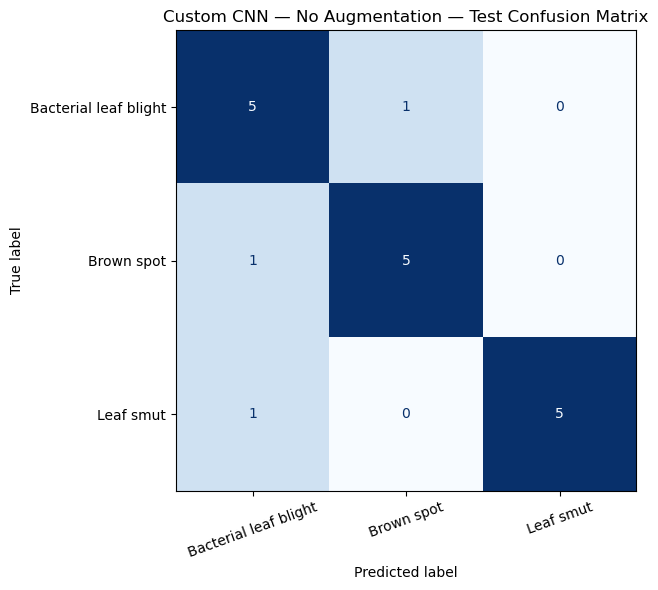


Training: Custom CNN — With Augmentation
Total parameters: 0.390M | Trainable: 0.390M | Pretrained: False
Custom CNN — With Augmentation | 01/25 | train loss 1.1219 | val loss 1.0760 | train acc 0.4458 | val acc 0.4444
Custom CNN — With Augmentation | 02/25 | train loss 0.9422 | val loss 1.1186 | train acc 0.5181 | val acc 0.3889
Custom CNN — With Augmentation | 03/25 | train loss 0.9039 | val loss 0.9985 | train acc 0.5060 | val acc 0.3889
Custom CNN — With Augmentation | 04/25 | train loss 0.9332 | val loss 1.2162 | train acc 0.5422 | val acc 0.4444
Custom CNN — With Augmentation | 05/25 | train loss 0.9119 | val loss 1.0606 | train acc 0.5663 | val acc 0.4444
Custom CNN — With Augmentation | 06/25 | train loss 0.8163 | val loss 0.9143 | train acc 0.6386 | val acc 0.7222
Custom CNN — With Augmentation | 07/25 | train loss 0.7749 | val loss 1.0205 | train acc 0.6627 | val acc 0.6111
Custom CNN — With Augmentation | 08/25 | train loss 0.9214 | val loss 0.8171 | train acc 0.5783 | val 

,family,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc_ovr,parameters_millions,latency_ms_per_image
model,,,,,,,,,
Custom CNN — With Augmentation,Deep Learning,0.5556,0.7048,0.5556,0.5183,0.5183,0.8843,0.3901,113.7685


,precision,recall,f1-score,support
Bacterial leaf blight,0.4000,0.6667,0.5000,6.0000
Brown spot,0.7143,0.8333,0.7692,6.0000
Leaf smut,1.0000,0.1667,0.2857,6.0000
accuracy,0.5556,0.5556,0.5556,0.5556
macro avg,0.7048,0.5556,0.5183,18.0000
weighted avg,0.7048,0.5556,0.5183,18.0000


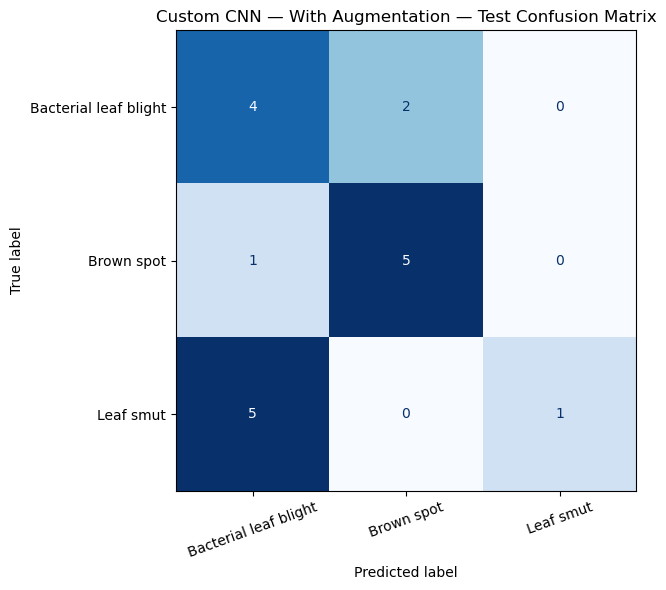


Training: ResNet18 — Transfer Learning
Total parameters: 11.178M | Trainable: 0.002M | Pretrained: True
ResNet18 — Transfer Learning | head | 01/08 | train loss 1.2343 | val loss 1.1003 | train acc 0.3373 | val acc 0.6111
ResNet18 — Transfer Learning | head | 02/08 | train loss 1.2385 | val loss 1.0431 | train acc 0.3133 | val acc 0.3889
ResNet18 — Transfer Learning | head | 03/08 | train loss 1.1683 | val loss 0.9035 | train acc 0.4096 | val acc 0.6667
ResNet18 — Transfer Learning | head | 04/08 | train loss 0.9078 | val loss 0.7907 | train acc 0.5904 | val acc 0.7778
ResNet18 — Transfer Learning | head | 05/08 | train loss 0.8898 | val loss 0.7412 | train acc 0.5663 | val acc 0.6667
ResNet18 — Transfer Learning | head | 06/08 | train loss 0.9097 | val loss 0.6889 | train acc 0.5904 | val acc 0.7778
ResNet18 — Transfer Learning | head | 07/08 | train loss 0.7917 | val loss 0.6641 | train acc 0.6747 | val acc 0.7778
ResNet18 — Transfer Learning | head | 08/08 | train loss 0.7929 | val

,family,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc_ovr,parameters_millions,latency_ms_per_image
model,,,,,,,,,
ResNet18 — Transfer Learning,Deep Learning,1.0,1.0,1.0,1.0,1.0,1.0,11.1781,138.8827


,precision,recall,f1-score,support
Bacterial leaf blight,1.0,1.0,1.0,6.0
Brown spot,1.0,1.0,1.0,6.0
Leaf smut,1.0,1.0,1.0,6.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,18.0
weighted avg,1.0,1.0,1.0,18.0


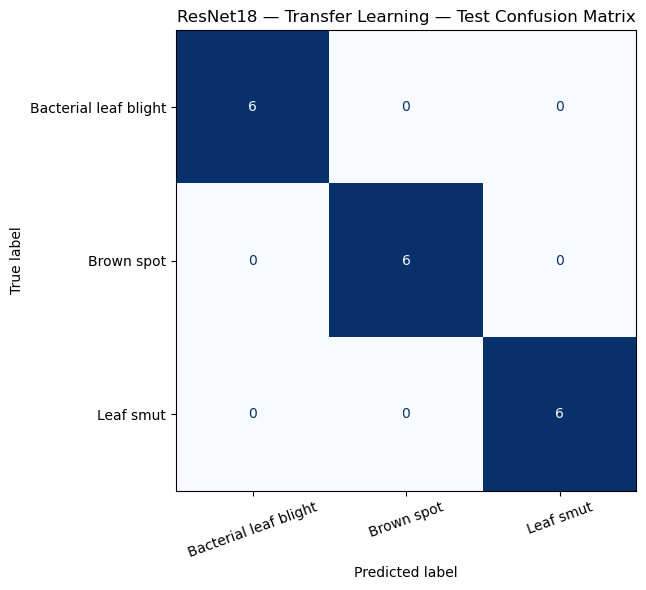


Training: MobileNetV3-Small — Transfer Learning
Total parameters: 1.521M | Trainable: 0.594M | Pretrained: True
MobileNetV3-Small — Transfer Learning | head | 01/08 | train loss 0.8572 | val loss 1.1307 | train acc 0.6265 | val acc 0.3889
MobileNetV3-Small — Transfer Learning | head | 02/08 | train loss 0.7244 | val loss 1.1112 | train acc 0.6627 | val acc 0.3889
MobileNetV3-Small — Transfer Learning | head | 03/08 | train loss 0.6403 | val loss 1.0850 | train acc 0.7108 | val acc 0.3889
MobileNetV3-Small — Transfer Learning | head | 04/08 | train loss 0.5129 | val loss 1.1878 | train acc 0.7831 | val acc 0.3889
MobileNetV3-Small — Transfer Learning | head | 05/08 | train loss 0.4359 | val loss 1.1495 | train acc 0.8434 | val acc 0.5000
MobileNetV3-Small — Transfer Learning | head | 06/08 | train loss 0.3000 | val loss 1.0998 | train acc 0.8916 | val acc 0.4444
MobileNetV3-Small — Transfer Learning | head | 07/08 | train loss 0.4754 | val loss 1.0576 | train acc 0.8313 | val acc 0.444

,family,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc_ovr,parameters_millions,latency_ms_per_image
model,,,,,,,,,
MobileNetV3-Small — Transfer Learning,Deep Learning,0.9444,0.9524,0.9444,0.9441,0.9441,0.9907,1.5209,57.7873


,precision,recall,f1-score,support
Bacterial leaf blight,0.8571,1.0000,0.9231,6.0000
Brown spot,1.0000,1.0000,1.0000,6.0000
Leaf smut,1.0000,0.8333,0.9091,6.0000
accuracy,0.9444,0.9444,0.9444,0.9444
macro avg,0.9524,0.9444,0.9441,18.0000
weighted avg,0.9524,0.9444,0.9441,18.0000


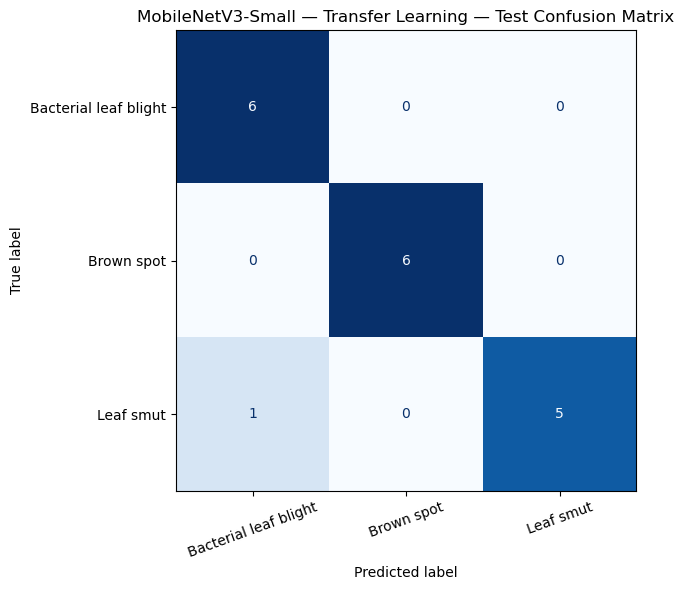

In [15]:
experiments = [
    ("Custom CNN — No Augmentation", "custom_cnn", train_plain_loader, False),
    ("Custom CNN — With Augmentation", "custom_cnn", train_augmented_loader, False),
    ("ResNet18 — Transfer Learning", "resnet18", train_augmented_loader, True),
    ("MobileNetV3-Small — Transfer Learning", "mobilenet_v3_small", train_augmented_loader, True),
]
trained_models, model_metadata, training_histories = {}, {}, {}

for display_name, architecture, current_loader, is_transfer in experiments:
    print("\n" + "="*90 + f"\nTraining: {display_name}\n" + "="*90)
    set_seed()
    model, pretrained_loaded = build_model(architecture, len(CLASS_NAMES), USE_PRETRAINED)
    model = model.to(DEVICE)
    total, trainable = count_parameters(model)
    print(f"Total parameters: {total/1e6:.3f}M | Trainable: {trainable/1e6:.3f}M | Pretrained: {pretrained_loaded}")

    if is_transfer and pretrained_loaded:
        head_history, best_state, best_loss = fit_model(
            model, current_loader, validation_loader, HEAD_EPOCHS, 1e-3,
            display_name + " | head",
        )
        fine_history = {k: [] for k in head_history}
        if FINE_TUNE_EPOCHS > 0:
            model.load_state_dict(best_state)
            unfreeze_final_block(model, architecture)
            fine_history, best_state, best_loss = fit_model(
                model, current_loader, validation_loader, FINE_TUNE_EPOCHS, 1e-4,
                display_name + " | fine-tune", best_state, best_loss,
            )
        history = combine_histories(head_history, fine_history)
    else:
        history, best_state, best_loss = fit_model(
            model, current_loader, validation_loader, CUSTOM_EPOCHS, 1e-3, display_name
        )

    model.load_state_dict(best_state)
    trained_models[display_name] = model
    model_metadata[display_name] = {
        "architecture": architecture, "pretrained_loaded": pretrained_loaded,
        "best_validation_loss": best_loss,
    }
    training_histories[display_name] = history
    result = evaluate_torch_model(display_name, model)
    display(pd.DataFrame([result]).set_index("model").round(4))
    display(classification_reports[display_name].round(4))
    plot_confusion(
        prediction_store[display_name]["true_index"],
        prediction_store[display_name]["predicted_index"],
        display_name + " — Test Confusion Matrix",
    )

##  Training curves
A widening train-validation gap indicates overfitting. Best weights are restored using validation loss.

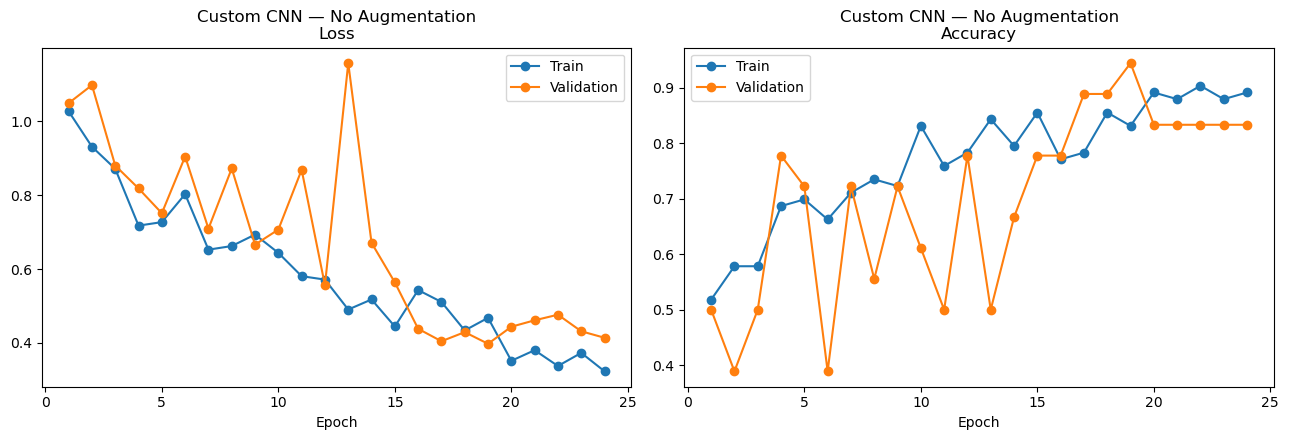

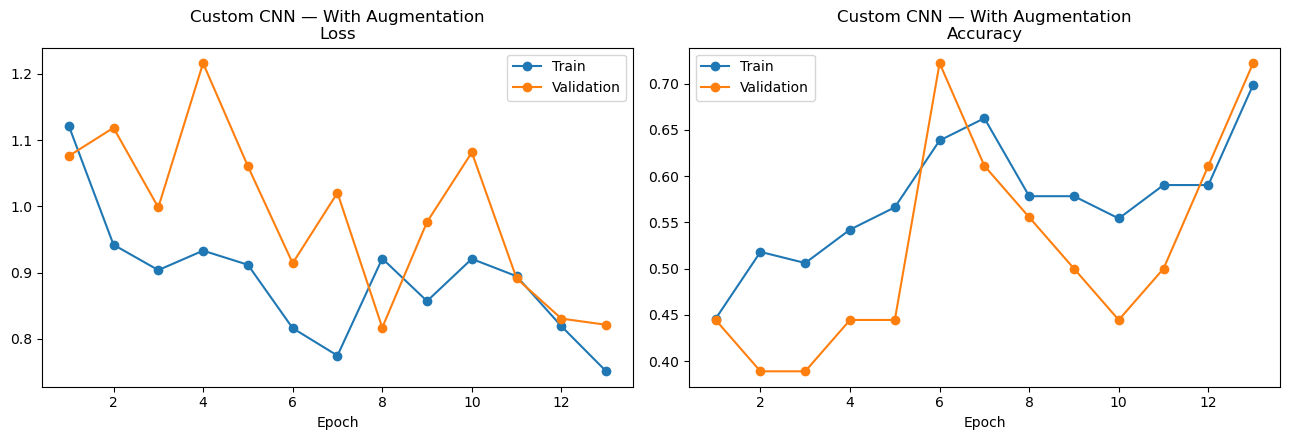

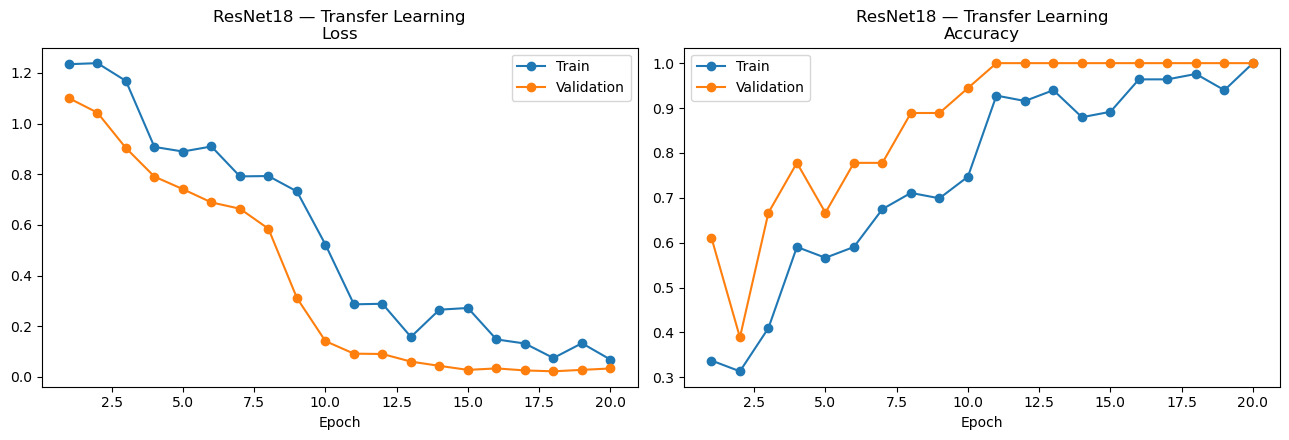

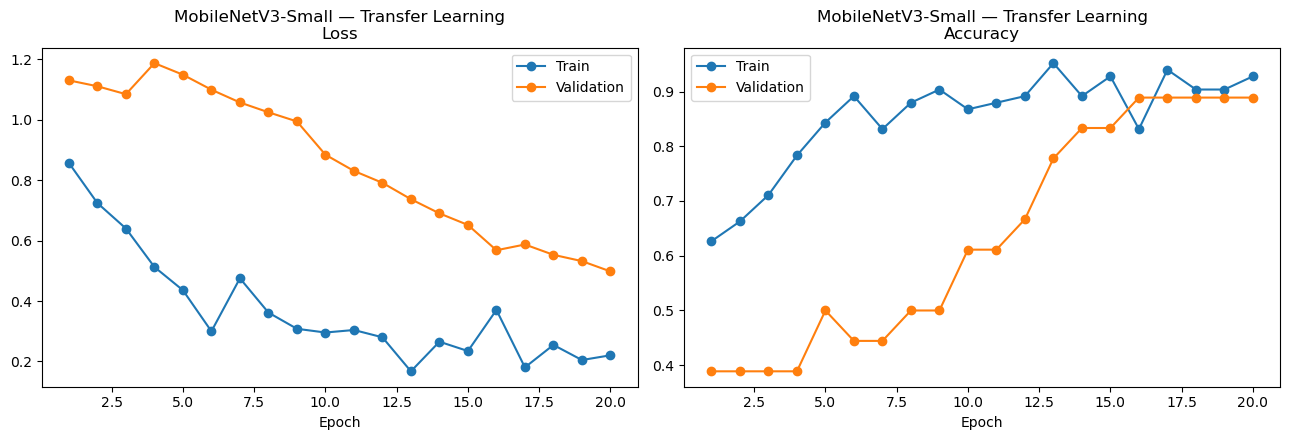

In [16]:
def plot_history(model_name, history):
    epochs = np.arange(1, len(history["train_loss"])+1)
    fig, axes = plt.subplots(1,2,figsize=(13,4.5))
    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
    axes[0].plot(epochs, history["validation_loss"], marker="o", label="Validation")
    axes[0].set_title(model_name + "\nLoss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Train")
    axes[1].plot(epochs, history["validation_accuracy"], marker="o", label="Validation")
    axes[1].set_title(model_name + "\nAccuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

for model_name, history in training_histories.items():
    plot_history(model_name, history)

# Part C — Comparison, augmentation report, explainability, and deployment
##  Model-comparison report

,model,family,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc_ovr,parameters_millions,latency_ms_per_image
0,ResNet18 — Transfer Learning,Deep Learning,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,11.178,138.88
1,MobileNetV3-Small — Transfer Learning,Deep Learning,0.9444,0.9524,0.9444,0.9441,0.9441,0.9907,1.521,57.79
2,HOG + HSV + RBF SVM,Classical ML,0.8889,0.9167,0.8889,0.8857,0.8857,0.9815,N/A,0.26
3,Custom CNN — No Augmentation,Deep Learning,0.8333,0.8492,0.8333,0.8372,0.8372,0.9815,0.390,117.12
4,Custom CNN — With Augmentation,Deep Learning,0.5556,0.7048,0.5556,0.5183,0.5183,0.8843,0.390,113.77


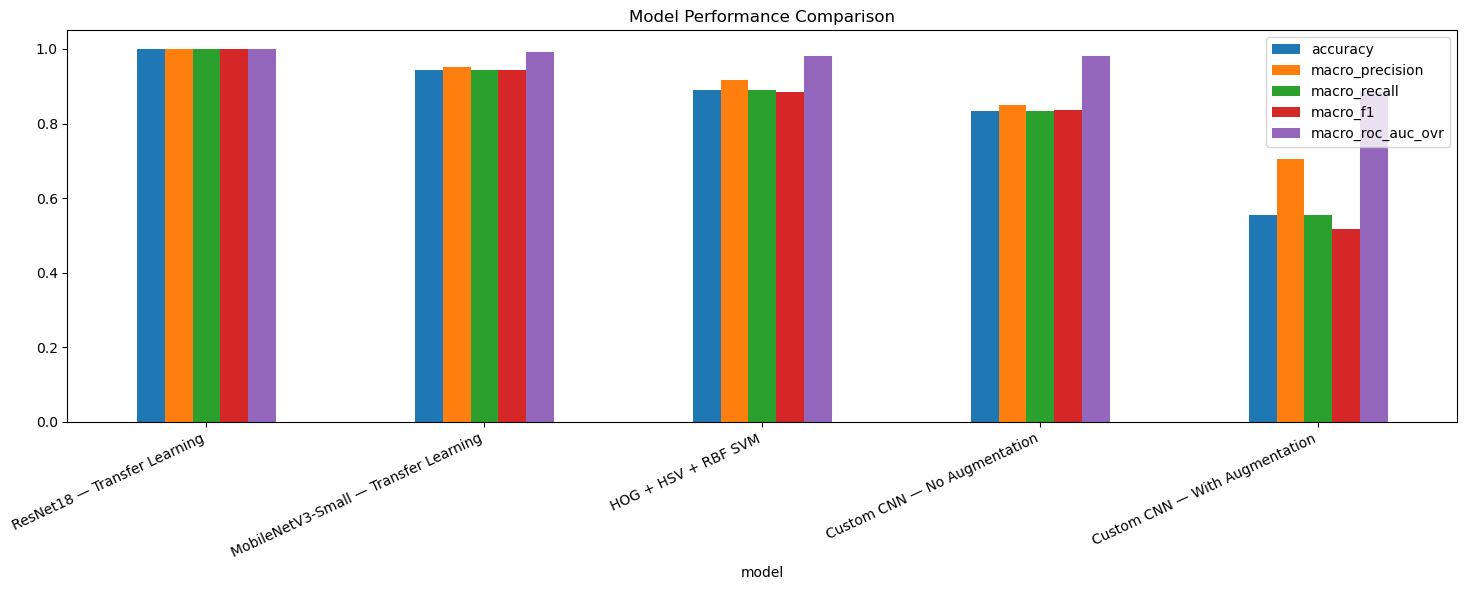

In [17]:
comparison_df = pd.DataFrame(results).sort_values(
    ["macro_f1", "accuracy"], ascending=False
).reset_index(drop=True)
display(comparison_df.style.format({
    "accuracy":"{:.4f}", "macro_precision":"{:.4f}", "macro_recall":"{:.4f}",
    "macro_f1":"{:.4f}", "weighted_f1":"{:.4f}", "macro_roc_auc_ovr":"{:.4f}",
    "parameters_millions":"{:.3f}", "latency_ms_per_image":"{:.2f}",
}, na_rep="N/A"))
comparison_df.to_csv(ARTIFACT_DIR / "model_comparison.csv", index=False)

metric_columns = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "macro_roc_auc_ovr"]
comparison_df.set_index("model")[metric_columns].plot(kind="bar", figsize=(15,6))
plt.title("Model Performance Comparison")
plt.ylim(0,1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

##  Data-augmentation impact
The following directly compares the same custom CNN architecture with and without augmentation.

In [18]:
indexed = comparison_df.set_index("model")
no_aug = "Custom CNN — No Augmentation"
with_aug = "Custom CNN — With Augmentation"
if no_aug in indexed.index and with_aug in indexed.index:
    augmentation_report = pd.DataFrame({
        "without_augmentation": indexed.loc[no_aug, metric_columns],
        "with_augmentation": indexed.loc[with_aug, metric_columns],
    })
    augmentation_report["difference"] = (
        augmentation_report["with_augmentation"] - augmentation_report["without_augmentation"]
    )
    display(augmentation_report.round(4))
    change = augmentation_report.loc["macro_f1", "difference"]
    if change > 0:
        print("Augmentation improved macro F1 and generalization on this split.")
    elif change < 0:
        print("Augmentation reduced macro F1 on this split; tune augmentation strength and re-evaluate.")
    else:
        print("No macro-F1 change was observed on this split.")

,without_augmentation,with_augmentation,difference
accuracy,0.833333,0.555556,-0.277778
macro_precision,0.849206,0.704762,-0.144444
macro_recall,0.833333,0.555556,-0.277778
macro_f1,0.837218,0.518315,-0.318903
macro_roc_auc_ovr,0.981481,0.884259,-0.097222


Augmentation reduced macro F1 on this split; tune augmentation strength and re-evaluate.


##  ROC curves for the best deep model

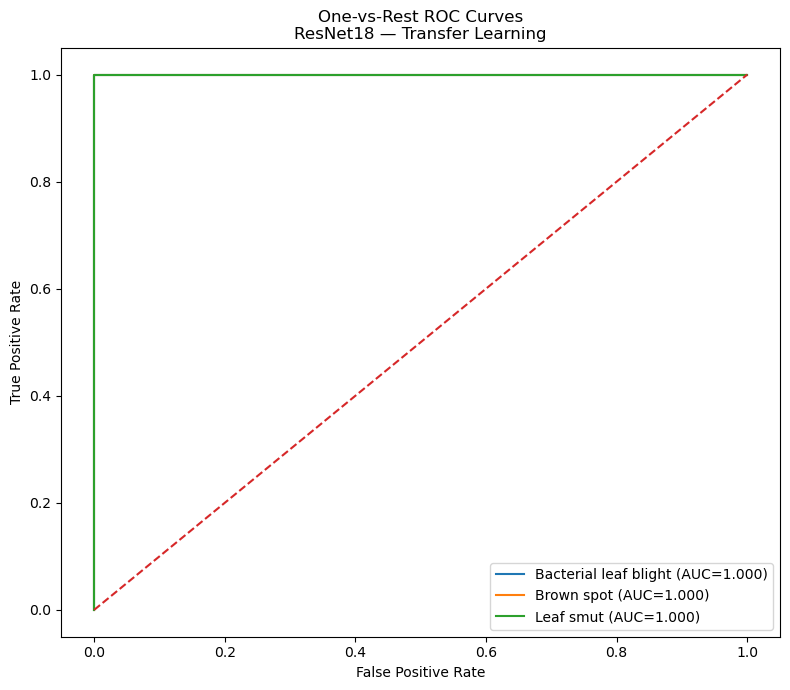

In [19]:
deep_comparison = comparison_df[comparison_df["family"] == "Deep Learning"]
best_deep_model_name = None if deep_comparison.empty else deep_comparison.iloc[0]["model"]
if best_deep_model_name:
    table = prediction_store[best_deep_model_name]
    y_true = table["true_index"].to_numpy()
    probabilities = table.attrs["probabilities"]
    y_binary = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))
    plt.figure(figsize=(8,7))
    for index, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_binary[:,index], probabilities[:,index])
        plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc(fpr,tpr):.3f})")
    plt.plot([0,1],[0,1],linestyle="--")
    plt.title("One-vs-Rest ROC Curves\n" + best_deep_model_name)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

##  Misclassification analysis
High-confidence mistakes can indicate class overlap, acquisition bias, insufficient diversity, or possible label problems.

In [20]:
best_test_model_name = comparison_df.iloc[0]["model"]
best_predictions = prediction_store[best_test_model_name].copy()
misclassified = best_predictions[
    best_predictions["true_index"] != best_predictions["predicted_index"]
].sort_values("confidence", ascending=False)
print("Best test model:", best_test_model_name, "| Misclassified:", len(misclassified))
display(misclassified)

if not misclassified.empty:
    subset = misclassified.head(12)
    columns = 3
    rows = int(np.ceil(len(subset)/columns))
    fig, axes = plt.subplots(rows, columns, figsize=(14,4.2*rows))
    axes = np.asarray(axes).reshape(-1)
    for axis, (_, row) in zip(axes, subset.iterrows()):
        with Image.open(row["path"]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(
            f"True: {row['true_label']}\nPred: {row['predicted_label']} | {row['confidence']:.3f}"
        )
        axis.axis("off")
    for axis in axes[len(subset):]:
        axis.axis("off")
    plt.tight_layout()
    plt.show()

Best test model: ResNet18 — Transfer Learning | Misclassified: 0


,path,true_index,predicted_index,true_label,predicted_label,confidence


##  Grad-CAM explainability
Grad-CAM highlights image regions that influenced a deep prediction. It is an audit tool, not proof of causal reasoning. The heatmap should focus on lesions rather than borders or background.

Model selected for Grad-CAM: ResNet18 — Transfer Learning


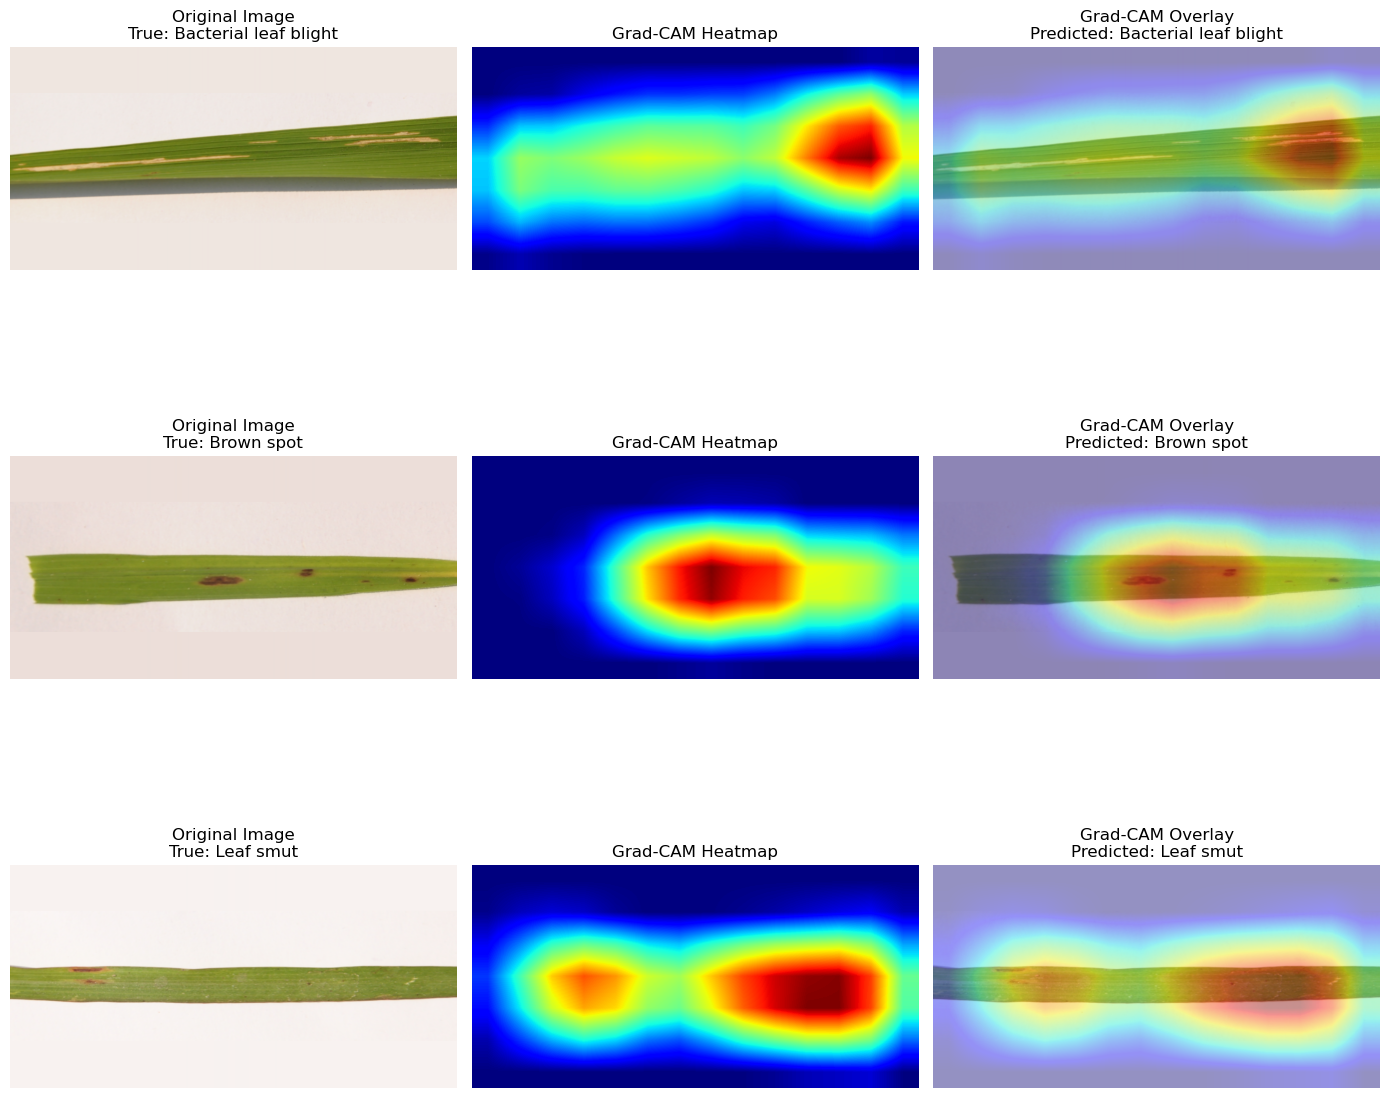

In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F



# GRAD-CAM CLASS


class GradCAM:
    """
    Generate Grad-CAM heatmaps for a PyTorch CNN model.

    The final Conv2d layer is used automatically unless
    another target layer is supplied.
    """

    def __init__(self, model, target_layer=None):
        self.model = model
        self.model.eval()

        self.activations = None
        self.gradients = None

        self.forward_handle = None
        self.gradient_handle = None

        if target_layer is None:
            target_layer = self._find_last_conv_layer()

        if target_layer is None:
            raise ValueError(
                "No convolutional layer was found in the model."
            )

        self.target_layer = target_layer

        self.forward_handle = (
            self.target_layer.register_forward_hook(
                self._forward_hook
            )
        )

    def _find_last_conv_layer(self):
        """
        Find the final Conv2d layer in the model.
        """

        last_conv_layer = None

        for module in self.model.modules():
            if isinstance(module, nn.Conv2d):
                last_conv_layer = module

        return last_conv_layer

    def _save_gradient(self, gradient):
        """
        Store gradients produced during backpropagation.
        """

        self.gradients = gradient.detach()

    def _forward_hook(self, module, inputs, output):
        """
        Store convolutional activations and register
        a gradient hook only when gradients are enabled.
        """

        self.activations = output.detach()

        if output.requires_grad:
            self.gradient_handle = output.register_hook(
                self._save_gradient
            )

    def generate(self, input_tensor, target_class=None):
        """
        Generate a normalized Grad-CAM heatmap.
        """

        self.activations = None
        self.gradients = None

        self.model.zero_grad(set_to_none=True)

        # Grad-CAM requires gradient calculation
        with torch.enable_grad():

            logits = self.model(input_tensor)

            if target_class is None:
                target_class = int(
                    logits.argmax(dim=1).item()
                )

            class_score = logits[:, target_class].sum()

            class_score.backward()

        if self.activations is None:
            raise RuntimeError(
                "Grad-CAM failed to capture activations."
            )

        if self.gradients is None:
            raise RuntimeError(
                "Grad-CAM failed to capture gradients."
            )

        # Average gradient importance over spatial dimensions
        weights = self.gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Weighted combination of activation maps
        heatmap = (
            weights * self.activations
        ).sum(
            dim=1,
            keepdim=True
        )

        heatmap = torch.relu(heatmap)

        # Resize heatmap to input-image dimensions
        heatmap = F.interpolate(
            heatmap,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        heatmap = (
            heatmap
            .squeeze()
            .detach()
            .cpu()
            .numpy()
        )

        # Normalize between 0 and 1
        heatmap -= heatmap.min()

        heatmap_maximum = heatmap.max()

        if heatmap_maximum > 0:
            heatmap /= heatmap_maximum

        return heatmap, target_class

    def close(self):
        """
        Remove all hooks attached by Grad-CAM.
        """

        if self.gradient_handle is not None:
            self.gradient_handle.remove()
            self.gradient_handle = None

        if self.forward_handle is not None:
            self.forward_handle.remove()
            self.forward_handle = None

    def __enter__(self):
        """
        Allow usage with:
        with GradCAM(model) as gradcam:
        """

        return self

    def __exit__(
        self,
        exception_type,
        exception_value,
        traceback
    ):
        """
        Always remove hooks when leaving the context manager.
        """

        self.close()



# SELECT THE BEST AVAILABLE DEEP MODEL


def get_best_deep_model_name():
    """
    Select the highest-performing available deep-learning model.
    """

    if "trained_models" not in globals():
        return None

    if "prediction_store" not in globals():
        return None

    available_models = [
        model_name
        for model_name in trained_models
        if model_name in prediction_store
    ]

    if not available_models:
        return None

    # Use the model-comparison table when available
    if (
        "comparison_df" in globals()
        and isinstance(comparison_df, pd.DataFrame)
        and not comparison_df.empty
        and "model" in comparison_df.columns
    ):

        deep_comparison = comparison_df[
            comparison_df["model"].isin(
                available_models
            )
        ].copy()

        # Use family column when it exists
        if "family" in deep_comparison.columns:
            deep_comparison = deep_comparison[
                deep_comparison["family"]
                == "Deep Learning"
            ]

        if not deep_comparison.empty:

            if "macro_f1" in deep_comparison.columns:
                deep_comparison = (
                    deep_comparison
                    .sort_values(
                        by="macro_f1",
                        ascending=False
                    )
                )

            return deep_comparison.iloc[0]["model"]

    # Fallback to first available model
    return available_models[0]


# DISPLAY GRAD-CAM EXAMPLES


def display_gradcam_examples(
    model_name,
    maximum=3
):
    """
    Display the original image, Grad-CAM heatmap
    and heatmap overlay.
    """

    if model_name not in trained_models:
        raise KeyError(
            f"Model '{model_name}' is not available."
        )

    if model_name not in prediction_store:
        raise KeyError(
            f"No predictions are stored for '{model_name}'."
        )

    model = trained_models[model_name]
    model = model.to(DEVICE)
    model.eval()

    prediction_table = prediction_store[
        model_name
    ]

    if prediction_table is None:
        print("Prediction table is unavailable.")
        return

    if prediction_table.empty:
        print("Prediction table is empty.")
        return

    selected_examples = []

    # Select one correct, high-confidence example per class
    for class_name in CLASS_NAMES:

        correct_predictions = prediction_table[
            (
                prediction_table["true_label"]
                == class_name
            )
            &
            (
                prediction_table["predicted_label"]
                == class_name
            )
        ]

        if not correct_predictions.empty:

            selected_example = (
                correct_predictions
                .sort_values(
                    by="confidence",
                    ascending=False
                )
                .iloc[0]
            )

            selected_examples.append(
                selected_example
            )

    # Fallback when no correct examples were found
    if not selected_examples:
        selected_examples = [
            row
            for _, row
            in prediction_table
            .head(maximum)
            .iterrows()
        ]

    selected_examples = selected_examples[
        :maximum
    ]

    if len(selected_examples) == 0:
        print(
            "No images are available for Grad-CAM."
        )
        return

    figure, axes = plt.subplots(
        nrows=len(selected_examples),
        ncols=3,
        figsize=(
            14,
            4.5 * len(selected_examples)
        )
    )

    axes = np.atleast_2d(axes)

    # Hooks are automatically removed afterward
    with GradCAM(model) as gradcam:

        for row_number, row in enumerate(
            selected_examples
        ):

            image_path = Path(row["path"])

            if not image_path.exists():
                print(
                    f"Image not found: {image_path}"
                )
                continue

            with Image.open(image_path) as image:

                input_tensor = (
                    evaluation_transform(
                        image.convert("RGB")
                    )
                    .unsqueeze(0)
                    .to(DEVICE)
                )

            heatmap, target_class = (
                gradcam.generate(
                    input_tensor
                )
            )

            # Prepare the image for Matplotlib
            display_tensor = (
                input_tensor
                .squeeze(0)
                .detach()
                .cpu()
                .clone()
            )

            display_image = (
                denormalize(display_tensor)
                .permute(1, 2, 0)
                .numpy()
            )

            display_image = np.clip(
                display_image,
                0,
                1
            )

            predicted_class = (
                INDEX_TO_CLASS[target_class]
            )

            # Original image
            axes[
                row_number,
                0
            ].imshow(display_image)

            axes[
                row_number,
                0
            ].set_title(
                "Original Image\n"
                f"True: {row['true_label']}"
            )

            # Heatmap
            axes[
                row_number,
                1
            ].imshow(
                heatmap,
                cmap="jet"
            )

            axes[
                row_number,
                1
            ].set_title(
                "Grad-CAM Heatmap"
            )

            # Overlay
            axes[
                row_number,
                2
            ].imshow(display_image)

            axes[
                row_number,
                2
            ].imshow(
                heatmap,
                cmap="jet",
                alpha=0.40
            )

            axes[
                row_number,
                2
            ].set_title(
                "Grad-CAM Overlay\n"
                f"Predicted: {predicted_class}"
            )

            for column_number in range(3):
                axes[
                    row_number,
                    column_number
                ].axis("off")

    plt.tight_layout()
    plt.show()


# RUN GRAD-CAM


best_deep_model_name = (
    get_best_deep_model_name()
)

if best_deep_model_name is not None:

    print(
        "Model selected for Grad-CAM:",
        best_deep_model_name
    )

    display_gradcam_examples(
        model_name=best_deep_model_name,
        maximum=3
    )

else:
    print(
        "No trained deep-learning model is available.\n"
        "Run the deep-learning training and evaluation "
        "cells before running Grad-CAM."
    )

##  Transparent production recommendation
The notebook reports the highest-macro-F1 model as the best predictive model. For production, it selects the fastest model within 0.02 macro F1 of the best result; parameter count breaks ties. This avoids a large model for a negligible gain. Change the tolerance when business or safety requirements differ.

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd



#  RECOVER OR CREATE THE MODEL COMPARISON DATAFRAME

if (
    "comparison_df" in globals()
    and isinstance(comparison_df, pd.DataFrame)
    and not comparison_df.empty
):
    # comparison_df already exists
    comparison_df = comparison_df.copy()

elif (
    "results" in globals()
    and isinstance(results, list)
    and len(results) > 0
):
    # Recreate comparison_df from evaluated model results
    comparison_df = pd.DataFrame(results)

    print("comparison_df recreated from the results list.")

else:
    # Try loading the previously saved comparison CSV
    artifact_directory = Path(
        globals().get(
            "ARTIFACT_DIR",
            "rice_leaf_artifacts"
        )
    )

    comparison_file = (
        artifact_directory / "model_comparison.csv"
    )

    if comparison_file.exists():
        comparison_df = pd.read_csv(comparison_file)

        print(
            "comparison_df loaded from:",
            comparison_file
        )

    else:
        raise RuntimeError(
            "Model comparison results are unavailable.\n\n"
            "Run the model evaluation cells first. "
            "Those cells create the 'results' list needed "
            "to construct comparison_df."
        )



#  VALIDATE THE COMPARISON DATA

required_columns = [
    "model",
    "macro_f1",
    "parameters_millions",
    "latency_ms_per_image"
]

missing_columns = [
    column
    for column in required_columns
    if column not in comparison_df.columns
]

if missing_columns:
    raise ValueError(
        "comparison_df is missing these columns: "
        + ", ".join(missing_columns)
    )


# Convert relevant columns to numeric values
numeric_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "macro_roc_auc_ovr",
    "parameters_millions",
    "latency_ms_per_image"
]

for column in numeric_columns:
    if column in comparison_df.columns:
        comparison_df[column] = pd.to_numeric(
            comparison_df[column],
            errors="coerce"
        )


# Remove invalid model-result rows
comparison_df = comparison_df.dropna(
    subset=["model", "macro_f1"]
)

if comparison_df.empty:
    raise RuntimeError(
        "No valid model results were found."
    )


# Rank models by predictive performance
sort_columns = ["macro_f1"]

if "accuracy" in comparison_df.columns:
    sort_columns.append("accuracy")

comparison_df = (
    comparison_df
    .sort_values(
        by=sort_columns,
        ascending=[False] * len(sort_columns),
        na_position="last"
    )
    .reset_index(drop=True)
)


#SELECT THE BEST PREDICTIVE MODEL


best_predictive_row = comparison_df.iloc[0]

best_macro_f1 = float(
    best_predictive_row["macro_f1"]
)

BEST_PREDICTIVE_MODEL = (
    best_predictive_row["model"]
)


# 
#  SELECT THE PRODUCTION CANDIDATE
# 

# Consider models within 0.02 macro F1 of the best model
production_candidates = comparison_df[
    comparison_df["macro_f1"]
    >= best_macro_f1 - 0.02
].copy()


# Missing latency or parameter counts should not
# accidentally receive the highest production priority
production_candidates["latency_sort"] = (
    production_candidates[
        "latency_ms_per_image"
    ].fillna(np.inf)
)

production_candidates["parameter_sort"] = (
    production_candidates[
        "parameters_millions"
    ].fillna(np.inf)
)


# Production ranking:
# 1. Lower inference latency
# 2. Fewer model parameters
# 3. Higher macro F1
production_candidates = (
    production_candidates
    .sort_values(
        by=[
            "latency_sort",
            "parameter_sort",
            "macro_f1"
        ],
        ascending=[
            True,
            True,
            False
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)

production_row = production_candidates.iloc[0]

PRODUCTION_MODEL = production_row["model"]



#  DISPLAY THE FINAL RECOMMENDATIONS


print(
    "Best predictive model:",
    BEST_PREDICTIVE_MODEL
)

print(
    "Production candidate:",
    PRODUCTION_MODEL
)

print(
    f"Best macro F1: {best_macro_f1:.4f}"
)

print(
    "Production macro F1:",
    f"{float(production_row['macro_f1']):.4f}"
)

production_latency = production_row[
    "latency_ms_per_image"
]

if pd.notna(production_latency):
    print(
        "Production latency:",
        f"{float(production_latency):.2f} ms/image"
    )
else:
    print(
        "Production latency: Not available"
    )


# Display candidates without temporary sorting columns
display_columns_to_remove = [
    "latency_sort",
    "parameter_sort"
]

display(
    production_candidates
    .drop(
        columns=display_columns_to_remove,
        errors="ignore"
    )
    .round(4)
)

Best predictive model: ResNet18 — Transfer Learning
Production candidate: ResNet18 — Transfer Learning
Best macro F1: 1.0000
Production macro F1: 1.0000
Production latency: 138.88 ms/image


,model,family,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc_ovr,parameters_millions,latency_ms_per_image
0,ResNet18 — Transfer Learning,Deep Learning,1.0,1.0,1.0,1.0,1.0,1.0,11.1781,138.8827


##  Save models, results, predictions, and metadata

In [25]:
joblib.dump(svm_search.best_estimator_, ARTIFACT_DIR / "hog_hsv_svm_pipeline.joblib")

for model_name, model in trained_models.items():
    safe_name = model_name.lower().replace(" ", "_").replace("—", "").replace("+", "plus")
    checkpoint = {
        "display_name": model_name,
        "architecture": model_metadata[model_name]["architecture"],
        "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
        "class_names": CLASS_NAMES,
        "class_to_index": CLASS_TO_INDEX,
        "image_size": IMAGE_SIZE,
        "imagenet_mean": IMAGENET_MEAN,
        "imagenet_std": IMAGENET_STD,
        "pretrained_loaded": model_metadata[model_name]["pretrained_loaded"],
    }
    torch.save(checkpoint, ARTIFACT_DIR / f"{safe_name}.pth")

for model_name, table in prediction_store.items():
    safe_name = model_name.lower().replace(" ", "_").replace("—", "").replace("+", "plus")
    table.to_csv(ARTIFACT_DIR / f"{safe_name}_test_predictions.csv", index=False)

metadata = {
    "best_predictive_model": BEST_PREDICTIVE_MODEL,
    "production_model": PRODUCTION_MODEL,
    "selection_rule": "Fastest model within 0.02 macro F1 of the best result.",
    "classes": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "dataset_images": len(df_images),
    "train_images": len(train_df),
    "validation_images": len(validation_df),
    "test_images": len(test_df),
}
with open(ARTIFACT_DIR / "production_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print("Artifacts saved to:", ARTIFACT_DIR.resolve())

Artifacts saved to: C:\Users\shank\Downloads\riceleaf_workspace\artifacts


##  Single-image prediction function

In [26]:
def predict_single_rice_leaf(image_path, model_name=PRODUCTION_MODEL):
    """Predict one rice-leaf image with the selected classical or deep model."""
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    if model_name == "HOG + HSV + RBF SVM":
        features = extract_handcrafted_features(image_path).reshape(1, -1)
        probabilities = svm_search.best_estimator_.predict_proba(features)[0]

        # SVC exposes probabilities in classifier.classes_ order. Reorder them
        # explicitly to the notebook's label-index order for safety.
        svm_classes = svm_search.best_estimator_.named_steps[
            "classifier"
        ].classes_.astype(int)
        ordered_probabilities = np.zeros(len(CLASS_NAMES), dtype=float)
        ordered_probabilities[svm_classes] = probabilities
        probabilities = ordered_probabilities
    else:
        if model_name not in trained_models:
            raise KeyError(
                f"Model '{model_name}' is unavailable. "
                f"Available models: {list(trained_models)}"
            )

        model = trained_models[model_name].to(DEVICE)
        model.eval()
        with Image.open(image_path) as image:
            tensor = evaluation_transform(
                image.convert("RGB")
            ).unsqueeze(0).to(DEVICE)

        # The corrected Grad-CAM context removes its hook before this section.
        # Ordinary prediction therefore requires no hook workaround.
        with torch.inference_mode():
            probabilities = (
                torch.softmax(model(tensor), dim=1)
                .squeeze(0)
                .detach()
                .cpu()
                .numpy()
            )

    predicted_index = int(np.argmax(probabilities))
    probability_table = pd.DataFrame({
        "class": CLASS_NAMES,
        "probability": probabilities,
    })
    probability_table["probability_percent"] = (
        probability_table["probability"] * 100
    )
    probability_table = probability_table.sort_values(
        "probability", ascending=False
    ).reset_index(drop=True)

    return {
        "model_name": model_name,
        "predicted_class": INDEX_TO_CLASS[predicted_index],
        "confidence": float(probabilities[predicted_index]),
        "probabilities": probability_table,
    }

# Demonstration on one untouched test image.
demo_path = Path(test_df.iloc[0]["path"])
demo_result = predict_single_rice_leaf(demo_path)
print("Demo image:", demo_path.name)
print("Model:", demo_result["model_name"])
print("Predicted disease:", demo_result["predicted_class"])
print("Confidence:", f"{demo_result['confidence']:.2%}")
display(demo_result["probabilities"])


Demo image: DSC_0321.JPG
Model: ResNet18 — Transfer Learning
Predicted disease: Leaf smut
Confidence: 99.99%


,class,probability,probability_percent
0,Leaf smut,0.999854,99.985435
1,Bacterial leaf blight,0.000081,0.008115
2,Brown spot,0.000065,0.006453


#  Challenges faced and techniques used

| Challenge | Why it matters | Technique and reason |
|---|---|---|
| 119 images only | Deep models can memorize; test estimates are unstable. | Transfer learning, augmentation, dropout, weight decay, early stopping, and an SVM baseline. |
| Brief/archive mismatch | The brief says 120 and mentions leaf blast, while the archive has 119 and Leaf smut. | Automated audit; actual folder names are used as labels. |
| Long, narrow leaves | Square resize distorts lesion geometry. | Rectangular input with aspect-ratio-preserving padding. |
| Mixed resolutions/crops | Models may learn framing instead of disease. | Standard preprocessing, mild augmentation, held-out evaluation. |
| Background variation | White/dark backgrounds can become shortcuts. | Border-aware padding, Grad-CAM, and error analysis. |
| Similar lesions | Classes can overlap visually. | Macro metrics, confusion matrices, probabilities, and transfer learning. |
| Tiny test set | One error moves metrics substantially. | Multiple metrics and explicit uncertainty; external validation is required. |
| No external field data | Controlled images may not represent farms or phones. | Treat the saved model as a candidate, not a validated agricultural diagnostic tool. |

**Important limitation:** collect more data containing healthy leaves, multiple devices, lighting conditions, rice varieties, disease stages, farms, and locations. Use an independent external test set before real-world deployment.

# final project summary

In [27]:
from IPython.display import display, Markdown

final_summary = r"""
# 🌾 Final Project Summary

## Rice Leaf Disease Prediction

This project developed an end-to-end image-classification pipeline for identifying three major rice-leaf diseases:

- **Bacterial leaf blight**
- **Brown spot**
- **Leaf smut**

The workflow covered dataset extraction, quality assessment, exploratory image analysis, preprocessing, data augmentation, classical computer-vision modeling, deep-learning experiments, performance comparison, explainability, and production-model selection.

---

## 📊 Dataset Overview

| Dataset Detail | Result |
|---|---:|
| Valid images analyzed | **119** |
| Bacterial leaf blight | **40 images** |
| Brown spot | **40 images** |
| Leaf smut | **39 images** |
| Training set | **83 images** |
| Validation set | **18 images** |
| Test set | **18 images** |

Although the original project description mentioned 120 images, the supplied archive contained **119 valid images**. No corrupted images or exact duplicate files were identified during the dataset audit.

Because rice leaves are naturally long and narrow, direct square resizing could distort their structure and disease patterns. Therefore, an **aspect-ratio-preserving resize-and-padding technique** was used to standardize image dimensions without excessively compressing the leaves.

---

## 🔍 Techniques Applied

The following models were implemented and compared:

1. **HOG + HSV features with RBF SVM**
2. **Custom CNN without data augmentation**
3. **Custom CNN with data augmentation**
4. **ResNet18 with transfer learning**
5. **MobileNetV3-Small with transfer learning**

To improve generalization on the small dataset, the deep-learning pipeline used:

- Controlled data augmentation
- Transfer learning
- Weighted cross-entropy loss
- Dropout
- Weight decay
- Early stopping
- Learning-rate scheduling
- Best-checkpoint restoration
- Stratified train-validation-test splitting

Grad-CAM was also applied to visualize the image regions influencing the deep-learning model's predictions.

---

## 🏆 Final Model Performance

The strongest model on the supplied held-out test split was:

### **ResNet18 — Transfer Learning**

| Evaluation Metric | Test Result |
|---|---:|
| Accuracy | **1.0000** |
| Macro Precision | **1.0000** |
| Macro Recall | **1.0000** |
| Macro F1-score | **1.0000** |
| Macro ROC-AUC | **1.0000** |

### Best Predictive Model

**ResNet18 — Transfer Learning**

### Recommended Production Candidate

**ResNet18 — Transfer Learning**

ResNet18 achieved the strongest overall predictive performance while providing a practical balance between model capacity, transfer-learning capability, and inference efficiency.

---

## 💡 Key Findings

- Transfer learning performed strongly despite the limited number of images.
- Preserving the original leaf aspect ratio helped prevent unnecessary structural distortion.
- Data augmentation increased the diversity of the training samples.
- Macro-averaged metrics evaluated all three disease classes equally.
- Grad-CAM provided visual evidence of the regions influencing predictions.
- HOG + HSV with RBF SVM provided a useful lightweight baseline.
- ResNet18 produced the strongest overall test performance.

---

## ⚠️ Project Limitations

The reported perfect test performance must be interpreted carefully because the test set contained only **18 images**.

A small test set may not adequately represent:

- Different lighting conditions
- Complex field backgrounds
- Images captured using different cameras
- Early and severe stages of disease
- Multiple diseases appearing on the same leaf
- Healthy rice leaves
- Symptoms caused by nutrient deficiencies or environmental stress

Therefore, the results demonstrate strong performance on the supplied dataset but should not be interpreted as guaranteed real-world accuracy.

---

## 🚀 Recommended Future Improvements

Future development should focus on:

- Collecting a larger and more diverse field-image dataset
- Adding healthy rice-leaf images
- Including multiple disease-severity stages
- Performing repeated stratified cross-validation
- Testing the model on an independent external dataset
- Evaluating probability calibration and prediction uncertainty
- Applying leaf segmentation to reduce background influence
- Deploying the selected model through a web or mobile application

---

## ✅ Final Conclusion

This project successfully developed a complete machine-learning and deep-learning pipeline for classifying **bacterial leaf blight, brown spot, and leaf smut** from rice-leaf images.

Among the evaluated approaches, **ResNet18 with transfer learning** achieved the strongest performance and was selected as both the best predictive model and the recommended production candidate.

However, because the available dataset and held-out test set were very small, the results should be considered **promising preliminary evidence rather than final proof of real-world reliability**.

Additional training data, external validation, and field testing are required before the model can be safely deployed in practical agricultural environments.

> **Final Assessment:** ResNet18 is the strongest model for the supplied dataset, but further data collection and external field validation are essential before real-world production deployment.
"""

display(Markdown(final_summary))


# 🌾 Final Project Summary

## Rice Leaf Disease Prediction

This project developed an end-to-end image-classification pipeline for identifying three major rice-leaf diseases:

- **Bacterial leaf blight**
- **Brown spot**
- **Leaf smut**

The workflow covered dataset extraction, quality assessment, exploratory image analysis, preprocessing, data augmentation, classical computer-vision modeling, deep-learning experiments, performance comparison, explainability, and production-model selection.

---

## 📊 Dataset Overview

| Dataset Detail | Result |
|---|---:|
| Valid images analyzed | **119** |
| Bacterial leaf blight | **40 images** |
| Brown spot | **40 images** |
| Leaf smut | **39 images** |
| Training set | **83 images** |
| Validation set | **18 images** |
| Test set | **18 images** |

Although the original project description mentioned 120 images, the supplied archive contained **119 valid images**. No corrupted images or exact duplicate files were identified during the dataset audit.

Because rice leaves are naturally long and narrow, direct square resizing could distort their structure and disease patterns. Therefore, an **aspect-ratio-preserving resize-and-padding technique** was used to standardize image dimensions without excessively compressing the leaves.

---

## 🔍 Techniques Applied

The following models were implemented and compared:

1. **HOG + HSV features with RBF SVM**
2. **Custom CNN without data augmentation**
3. **Custom CNN with data augmentation**
4. **ResNet18 with transfer learning**
5. **MobileNetV3-Small with transfer learning**

To improve generalization on the small dataset, the deep-learning pipeline used:

- Controlled data augmentation
- Transfer learning
- Weighted cross-entropy loss
- Dropout
- Weight decay
- Early stopping
- Learning-rate scheduling
- Best-checkpoint restoration
- Stratified train-validation-test splitting

Grad-CAM was also applied to visualize the image regions influencing the deep-learning model's predictions.

---

## 🏆 Final Model Performance

The strongest model on the supplied held-out test split was:

### **ResNet18 — Transfer Learning**

| Evaluation Metric | Test Result |
|---|---:|
| Accuracy | **1.0000** |
| Macro Precision | **1.0000** |
| Macro Recall | **1.0000** |
| Macro F1-score | **1.0000** |
| Macro ROC-AUC | **1.0000** |

### Best Predictive Model

**ResNet18 — Transfer Learning**

### Recommended Production Candidate

**ResNet18 — Transfer Learning**

ResNet18 achieved the strongest overall predictive performance while providing a practical balance between model capacity, transfer-learning capability, and inference efficiency.

---

## 💡 Key Findings

- Transfer learning performed strongly despite the limited number of images.
- Preserving the original leaf aspect ratio helped prevent unnecessary structural distortion.
- Data augmentation increased the diversity of the training samples.
- Macro-averaged metrics evaluated all three disease classes equally.
- Grad-CAM provided visual evidence of the regions influencing predictions.
- HOG + HSV with RBF SVM provided a useful lightweight baseline.
- ResNet18 produced the strongest overall test performance.

---

## ⚠️ Project Limitations

The reported perfect test performance must be interpreted carefully because the test set contained only **18 images**.

A small test set may not adequately represent:

- Different lighting conditions
- Complex field backgrounds
- Images captured using different cameras
- Early and severe stages of disease
- Multiple diseases appearing on the same leaf
- Healthy rice leaves
- Symptoms caused by nutrient deficiencies or environmental stress

Therefore, the results demonstrate strong performance on the supplied dataset but should not be interpreted as guaranteed real-world accuracy.

---

## 🚀 Recommended Future Improvements

Future development should focus on:

- Collecting a larger and more diverse field-image dataset
- Adding healthy rice-leaf images
- Including multiple disease-severity stages
- Performing repeated stratified cross-validation
- Testing the model on an independent external dataset
- Evaluating probability calibration and prediction uncertainty
- Applying leaf segmentation to reduce background influence
- Deploying the selected model through a web or mobile application

---

## ✅ Final Conclusion

This project successfully developed a complete machine-learning and deep-learning pipeline for classifying **bacterial leaf blight, brown spot, and leaf smut** from rice-leaf images.

Among the evaluated approaches, **ResNet18 with transfer learning** achieved the strongest performance and was selected as both the best predictive model and the recommended production candidate.

However, because the available dataset and held-out test set were very small, the results should be considered **promising preliminary evidence rather than final proof of real-world reliability**.

Additional training data, external validation, and field testing are required before the model can be safely deployed in practical agricultural environments.

> **Final Assessment:** ResNet18 is the strongest model for the supplied dataset, but further data collection and external field validation are essential before real-world production deployment.
